# Examen Parcial · Redes Neuronales y Aprendizaje Profundo · UNI FIIS 2026-II
## Pregunta 1 · Clasificación multietiqueta de anomalías de rodilla en RM (CNN + supervisión débil)

**Integrantes**
1. Cánepa Maceda, Jhafet Martín
2. Coaguila Berrios, Hipólito
3. Jhon Anderson
4.
5.
6.



## 0. Diseño experimental

| Decisión | Elección | Justificación |
|---|---|---|
| Supervisión | Etiquetas débiles extraídas del reporte (reglas multilingües + negación + severidad) con **target suave** y **peso de confianza** por celda | Los criterios oficiales tienen umbrales de severidad (p. ej. derrame *moderado o grande*), por lo que una mención no equivale a un positivo |
| Validación limpia | Los 58 estudios con etiqueta dorada **nunca** entran al entrenamiento ni a la selección de umbrales | Evita fuga de información hacia la única fuente de verdad |
| Umbrales | Se eligen por etiqueta maximizando F1 en un *holdout* de etiquetas débiles y se aplican al conjunto dorado | Elegirlos en el conjunto dorado sobreestimaría precisión/recall |
| Escala | Subconjunto estratificado (400 estudios de entrenamiento + 60 de holdout débil), 1 o 2 planos (sagital fluido-sensible con supresión grasa; coronal para ablación), volúmenes 2.5D de tripletes de cortes | Recomendación explícita del enunciado; el plano sagital es el de referencia para LCA, meniscos y derrame |
| Modelos | (a) CNN 2.5D desde cero con SE y *attention-MIL* sobre cortes; (b) backbone ImageNet (`resnet50` por defecto) con la misma cabeza de agregación y 12 salidas sigmoides | Comparación justa: mismo muestreo, misma agregación, misma cabeza |
| Ablación | Función de pérdida (BCE vs. focal), manejo de ruido (ponderado vs. solo alta confianza vs. sin ponderar), plano (sagital vs. coronal), profundidad del backbone, sobre-muestreo de positivos raros | Cubre los factores pedidos en el entregable 4 |
| Interpretabilidad | Grad-CAM sobre el último mapa convolucional del corte con mayor atención | Permite juzgar plausibilidad anatómica por hallazgo |

**Modos de ejecución** (se detectan automáticamente):
- `kaggle`: datos montados en `/kaggle/input/rsna-knee-abnormality-detection` (GPU recomendada).
- `cache`: entrenamiento en Colab a partir de la caché `.npz` exportada desde Kaggle como *dataset* privado (ver README).
- `mock`: fixture sintético con el mismo esquema (DICOM reales, reportes multilingües) para verificar el pipeline de extremo a extremo sin datos.

## 1. Entorno

In [1]:
import importlib, subprocess, sys

for pkg, spec in (("pydicom", "pydicom>=2.4"), ("timm", "timm>=0.9")):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", spec], check=True)

import copy, dataclasses, json, math, os, random, re, time, unicodedata, warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
from dataclasses import dataclass, field, asdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import ExplicitVRLittleEndian, generate_uid
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset as TorchDataset, WeightedRandomSampler

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print(f"torch {torch.__version__} | cuda={torch.cuda.is_available()} | pydicom {pydicom.__version__}")


torch 2.11.0+cu128 | cuda=True | pydicom 3.0.2


## 2. Configuración

Un único `dataclass` gobierna rutas, muestreo, arquitectura, pérdida y estrategia de ruido. Cada experimento de la ablación es un `dataclasses.replace` sobre esta configuración, lo que garantiza que solo cambie el factor estudiado.

In [2]:
import os
import random
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np

LABELS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]


def detect_data_root() -> Path:
    kaggle = Path("/kaggle/input/rsna-knee-abnormality-detection")
    if kaggle.exists():
        return kaggle
    env = os.environ.get("KNEE_DATA_ROOT")
    if env:
        return Path(env)
    return Path("data/rsna-knee")


@dataclass
class Config:
    data_root: Path = field(default_factory=detect_data_root)
    work_dir: Path = Path("work")
    seed: int = 42

    report_col: str | None = None
    n_train_studies: int = 400
    min_pos_per_label: int = 15
    n_weak_holdout: int = 60

    planes: tuple[str, ...] = ("Sagittal",)
    prefer_fluid_sensitive: bool = True
    prefer_fat_suppression: bool = True
    target_slices: int = 32
    img_size: int = 224
    slices_per_study: int = 8
    triplet_gap: int = 1
    depth_range: tuple[float, float] = (0.10, 0.90)
    window_pct: tuple[float, float] = (1.0, 99.0)

    arch: str = "scratch"
    backbone: str = "resnet50"
    pretrained: bool = True
    pool: str = "attention"
    dropout: float = 0.3

    loss: str = "bce"
    focal_gamma: float = 2.0
    focal_alpha: float = 0.25
    noise_strategy: str = "weighted"
    high_conf_threshold: float = 0.7
    use_pos_weight: bool = False
    pos_weight_cap: float = 8.0
    oversample_rare: bool = True

    epochs: int = 12
    batch_size: int = 8
    lr: float = 3e-4
    backbone_lr_scale: float = 0.1
    weight_decay: float = 1e-4
    warmup_epochs: int = 1
    patience: int = 4
    grad_clip: float = 2.0
    amp: bool = True
    num_workers: int = 2

    mock: bool = False
    mock_studies: int = 90
    mock_slices: int = 14
    mock_size: int = 64

    def __post_init__(self) -> None:
        self.data_root = Path(self.data_root)
        self.work_dir = Path(self.work_dir)
        self.work_dir.mkdir(parents=True, exist_ok=True)

    @property
    def cache_dir(self) -> Path:
        d = self.work_dir / f"cache_{self.img_size}"
        d.mkdir(parents=True, exist_ok=True)
        return d

    @property
    def dicom_dir(self) -> Path:
        return self.data_root / "train_series"

    def to_dict(self) -> dict:
        d = asdict(self)
        d["data_root"] = str(self.data_root)
        d["work_dir"] = str(self.work_dir)
        return d


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
    except ImportError:
        pass


## 3. Módulo de etiquetas débiles multilingües (Entregable 1)


El extractor trabaja a nivel de **cláusula** (frase separada por `.`, `;`, `,` y conjunciones) y, para cada una de las 12 etiquetas, resuelve un estado:

| Estado | Target | Peso | Ejemplo |
|---|---|---|---|
| `pos_strong` | 0.95 | 1.00 | "rotura completa del LCA", "derrame moderado", quiste ≥ 3 cm |
| `pos` | 0.85 | 0.85 | "rotura del cuerno posterior del menisco medial" |
| `uncertain` | 0.60 | 0.50 | "posible rotura parcial", "no se descarta fractura" |
| `below_cut` | 0.25 | 0.60 | "derrame mínimo", "esguince grado 1 del LCM", "fractura antigua consolidada" |
| `neg` | 0.05 | 1.00 | "sin derrame", "eklem içi sıvı izlenmedi", "LCA íntegro" |
| `ambiguous` | 0.35 | 0.30 | estructura mencionada sin cue de patología ni normalidad |
| `unmentioned` | 0.05 | 0.35 | el reporte no habla del hallazgo (frecuente en sinovitis y fractura) |

Decisiones de diseño relevantes:
- **Negación bidireccional.** Idiomas como el turco niegan después del término (`izlenmedi`, `saptanmadı`); un detector solo de ventana izquierda invierte esas etiquetas. Se buscan cues antes del término anatómico y, después de él, solo si van seguidos de un término negable (patología o "alteraciones/cambios").
- **Severidad por criterio oficial.** Derrame y quiste de Baker son positivos solo si son *moderados o grandes*; se parsean tamaños en mm/cm. "Moderado/mäßig/modéré" se clasifica como mayor, nunca como menor.
- **Normalización Unicode** que elimina diacríticos latinos y griegos pero preserva los cirílicos (la NFKD descompondría `й`), más transliteración de `ı ł ø đ ß œ`.
- **Identificación de idioma** por *stopwords* y escritura (cirílico, griego) sin dependencias externas, usada solo para el análisis de sesgo lingüístico.
- Un segundo etiquetador de bajo costo (`TfidfLabeler`: n-gramas de caracteres + regresión logística uno-contra-resto) se entrena con las etiquetas de reglas de alta confianza y se compara contra el conjunto dorado como referencia.

In [3]:
import re
import unicodedata
from dataclasses import dataclass

import numpy as np
import pandas as pd


_TRANSLIT = str.maketrans({"ı": "i", "ł": "l", "ø": "o", "đ": "d", "ß": "ss", "µ": "μ", "œ": "oe", "æ": "ae"})


def normalize(text: str) -> str:
    if not isinstance(text, str):
        return ""
    out: list[str] = []
    for c in unicodedata.normalize("NFKD", text.lower().translate(_TRANSLIT)):
        if unicodedata.combining(c) and not (out and "\u0400" <= out[-1] <= "\u04ff"):
            continue
        out.append(c)
    t = unicodedata.normalize("NFC", "".join(out))
    return re.sub(r"[ \t]+", " ", t)


_STOPWORDS = {
    "en": "the and of with is are no there normal without right left knee tear seen",
    "es": "el la de los las con sin del se no hay derecha izquierda rodilla una observa",
    "pt": "o a os as de do da com sem nao joelho direito esquerdo uma observa",
    "fr": "le la les des du de et avec sans pas genou droit gauche une est",
    "de": "der die das und mit ohne kein keine nicht im knie rechts links ist",
    "it": "il la di del della con senza non ginocchio destro sinistro una e",
    "nl": "de het van en met zonder geen niet knie rechter linker een is",
    "pl": "i w z na nie bez brak kolano prawe lewe jest oraz",
    "tr": "ve ile izlenmedi izlendi saptanmadi saptandi diz sag sol mevcut olarak",
    "hr": "i u na s bez nema koljeno desno lijevo je uredan uredna te",
}
_STOP_SETS = {k: set(v.split()) for k, v in _STOPWORDS.items()}


def detect_language(text: str) -> str:
    raw = text if isinstance(text, str) else ""
    if re.search(r"[Ѐ-ӿ]", raw):
        return "ru"
    if re.search(r"[Ͱ-Ͽ]", raw):
        return "el"
    tokens = re.findall(r"[a-z]+", normalize(raw))
    if not tokens:
        return "unknown"
    scores = {lang: sum(t in sw for t in tokens) for lang, sw in _STOP_SETS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] >= 2 else "unknown"


def _rx(*alts: str) -> re.Pattern:
    return re.compile("|".join(alts))


NEG_PRE = _rx(
    r"\bno\b", r"\bsin\b", r"\bausencia\b", r"\bnot\b", r"\bwithout\b", r"\bfree of\b",
    r"\bnegative for\b", r"\bkein\w*\b", r"\bnicht\b", r"\bohne\b", r"\bpas d[e']", r"\bsans\b",
    r"\babsence\b", r"\bnessun\w*\b", r"\bassenza\b", r"\bnon\b", r"\bgeen\b", r"\bzonder\b",
    r"\bbrak\b", r"\bnie\b", r"\bbez\b", r"\bнет\b", r"\bбез\b", r"\bне\b", r"\bδεν\b",
    r"\bχωρις\b", r"\bnema\b", r"\bnao\b", r"\bnem\b", r"\bsem\b", r"\bni\b", r"\bnor\b", r"\bnoch\b",
    r"\bne\b", r"\bani\b", r"\bни\b", r"\bουτε\b", r"\bniti\b", r"\bexclu\w*\b", r"\bdescart\w*\b",
    r"\bausgeschlossen\b", r"\bnegativ\w*\b",
)
NEG_POST = _rx(
    r"izlenmedi", r"izlenmemistir", r"saptanmadi", r"saptanmamistir", r"gorulmedi",
    r"mevcut degil", r"bulunmamaktadir", r"\byok\b", r"\bnegativ\w*\b", r"not seen", r"not identified",
    r"is not\b", r"are not\b", r"no se (?:observa|identifica|evidencia)", r"nao se (?:observa|identifica)",
    r"n'est pas", r"ne sont pas", r"non si (?:osserva|evidenzia)", r"niet (?:aanwezig|zichtbaar)",
    r"nie stwierdz\w*", r"не (?:выявл|определ|визуализ)\w*", r"δεν (?:παρατηρ|διαπιστ)\w*",
    r"nije (?:vidljiv|uocen|nadjen)\w*", r"nem (?:lathato|eszlelheto)",
)
NORMAL_CUES = _rx(
    r"\bnormal\w*\b", r"\bintact\w*\b", r"\bintegr\w*\b", r"\bregelrecht\w*\b", r"\bunauffallig\w*\b",
    r"\bconservad\w*\b", r"\bpreservad\w*\b", r"\bpreserved\b", r"\bsaglam\b", r"\bintakt\w*\b",
    r"\bprawidlow\w*\b", r"\bnienaruszon\w*\b", r"\bцел\w*\b", r"\bнормальн\w*\b", r"\bсохранен\w*\b",
    r"\bне изменен\w*\b", r"\bφυσιολογ\w*\b", r"\bακεραι\w*\b", r"\bured[an]\w*\b", r"\bocuvan\w*\b",
    r"\bintatt\w*\b", r"\bunremarkable\b", r"\bwithin normal limits\b", r"\bphysiolog\w*\b",
    r"\bfisiolog\w*\b", r"\bfizjolog\w*\b", r"\bfizyolojik\b", r"\bфизиологич\w*\b", r"\bfiziolos\w*\b",
    r"\bhomogene\w*\b", r"\bindemne\b", r"\bindenne\b", r"\bnei limiti\b", r"\bnella norma\b",
    r"\bdans les limites\b", r"\bin ordnung\b", r"\bw normie\b", r"\bв пределах нормы\b", r"\bsinirlar\w*\b",
    r"\bu granicama\b", r"\bsin particularidades\b", r"\bsem particularidades\b", r"\bno abnormalit\w*\b",
)
UNCERTAIN_CUES = _rx(
    r"\bpossibl\w*\b", r"\bposibl\w*\b", r"\bprobabl\w*\b", r"\blikely\b", r"\bsuspect\w*\b",
    r"\bsospech\w*\b", r"\bcannot (?:be )?exclude\w*\b", r"\bno se descarta\b", r"\bmay represent\b",
    r"\bkonnte\b", r"\bmoglich\w*\b", r"\bverdacht\w*\b", r"\bsuspicion\b", r"\bsuspicieu\w*\b",
    r"\bpossibil\w*\b", r"\bsospett\w*\b", r"\bmogelijk\w*\b", r"\bverdenking\b", r"\bmozliw\w*\b",
    r"\bpodejrzen\w*\b", r"\bolasi\b", r"\bsuphe\w*\b", r"\bвозможн\w*\b", r"\bподозрен\w*\b",
    r"\bπιθαν\w*\b", r"\bmoguc\w*\b", r"\bsumnj\w*\b", r"\?", r"\bequivocal\b", r"\bdudos\w*\b",
    r"\bversus\b", r"\bvs\.?\b", r"\bpartial\w*\b", r"\bparcial\w*\b", r"\bpartiel\w*\b",
    r"\bparzial\w*\b", r"\bpartiel\w*\b", r"\bteilruptur\w*\b", r"\bteil\w*\b", r"\bkismi\b",
    r"\bczesciow\w*\b", r"\bчастичн\w*\b", r"\bμερικ\w*\b", r"\bdjelomic\w*\b",
)
PATHO_CUES = _rx(
    r"\btear\w*\b", r"\btorn\b", r"\brotur\w*\b", r"\bruptur\w*\b", r"\bdesgarr\w*\b", r"\blesion\w*\b",
    r"\binjur\w*\b", r"\briss\b", r"\bdechirur\w*\b", r"\blaceraz\w*\b", r"\bscheur\w*\b",
    r"\bletsel\b", r"\buszkodz\w*\b", r"\bpekniec\w*\b", r"\byirtik\w*\b", r"\bhasar\w*\b",
    r"\bразрыв\w*\b", r"\bповрежден\w*\b", r"\bρηξ\w*\b", r"\bβλαβ\w*\b", r"\bostecen\w*\b",
    r"\bedema\w*\b", r"\bedem\b", r"\bodem\w*\b", r"\boedem\w*\b", r"\bobrzek\w*\b", r"\bотек\w*\b",
    r"\bοιδημ\w*\b", r"\bsprain\w*\b", r"\besguinc\w*\b", r"\bdistors\w*\b", r"\bdegenera\w*\b",
    r"\bchondromalac\w*\b", r"\bcondromalac\w*\b", r"\bchondropath\w*\b", r"\bcondropat\w*\b",
    r"\bcartilage loss\b", r"\bperdida\b", r"\bthinning\b", r"\badelgaz\w*\b", r"\bosteofit\w*\b",
    r"\bosteophyt\w*\b", r"\bsubchondral\w*\b", r"\bsubcondral\w*\b", r"\bnarrowing\b",
    r"\bestrechamiento\b", r"\bgrade\b", r"\bgrado\b", r"\bgrad\b", r"\bfissur\w*\b", r"\bfisur\w*\b",
    r"\bdefect\w*\b", r"\bdefekt\w*\b", r"\bfull[- ]thickness\b", r"\bespesor total\b",
    r"\bcomplex\w*\b", r"\bcomplej\w*\b", r"\bbucket\b", r"\basa de balde\b", r"\bextru\w*\b",
    r"\btruncat\w*\b", r"\bdisplac\w*\b", r"\bdesplaz\w*\b", r"\bdiscontinu\w*\b", r"\babsent\b",
    r"\bausent\w*\b", r"\bavuls\w*\b", r"\barthros\w*\b", r"\bartros\w*\b", r"\bosteoarthr\w*\b",
    r"\bgonarthr\w*\b", r"\bgonartr\w*\b", r"\bdegenerativ\w*\b", r"\bsurface\b", r"\bsuperficie\b",
    r"\bradial\b", r"\bhorizontal\b", r"\bflap\b", r"\bkellgren\b", r"\bчастичн\w*\b",
    r"\bдегенерат\w*\b", r"\bистончен\w*\b", r"\bεκφυλ\w*\b", r"\bdegenerac\w*\b", r"\bzwyrodnien\w*\b",
    r"\bdejenera\w*\b", r"\bkopma\w*\b", r"\bincelme\w*\b", r"\bdisruption\b", r"\bdisrupt\w*\b",
    r"\bhigh[- ]grade\b", r"\balto grado\b", r"\bcomplet\w*\b", r"\bvollstandig\w*\b", r"\btam kat\b",
    r"\bkayb\w*\b", r"\badvanced\b", r"\bavanzad\w*\b", r"\bfortgeschritten\w*\b", r"\bevolue\w*\b",
    r"\bavance\w*\b", r"\bavanzat\w*\b", r"\bgevorderd\w*\b", r"\bzaawansowan\w*\b", r"\bileri\b",
    r"\bschaden\b", r"\bknorpelschaden\b", r"\bkaybi\b",
)
NEGATABLE = _rx(
    PATHO_CUES.pattern, r"\balterac\w*\b", r"\balterazion\w*\b", r"\banomal\w*\b",
    r"\babnormal\w*\b", r"\bafwijking\w*\b", r"\bzmian\w*\b", r"\bpromjen\w*\b", r"\bизменен\w*\b",
    r"\bαλλοιωσ\w*\b", r"\bbefund\w*\b", r"\bchange\w*\b", r"\bcambio\w*\b", r"\bevidence\b",
    r"\bevidencia\b", r"\bsignos?\b", r"\bsign\w*\b", r"\bsinais\b", r"\bsegni\b", r"\bnachweis\b",
    r"\bparticularit\w*\b", r"\bhallazgo\w*\b", r"\bpatholog\w*\b", r"\bpatolog\w*\b", r"\bsignificant\w*\b",
)
NEG_WORD = _rx(
    r"\bno\b", r"\bnot\b", r"\bwithout\b", r"\bsin\b", r"\bsem\b", r"\bsans\b", r"\bsenza\b", r"\bnon\b",
    r"\bohne\b", r"\bkein\w*\b", r"\bnicht\b", r"\bzonder\b", r"\bgeen\b", r"\bniet\b", r"\bbez\b",
    r"\bbrak\b", r"\bnie\b", r"\bбез\b", r"\bнет\b", r"\bне\b", r"\bχωρις\b", r"\bδεν\b", r"\bnema\b",
    r"\bnao\b", r"\bnem\b", r"\bfree of\b", r"\bnegative for\b",
)
STRONG_POS = _rx(
    r"\bcomplete\b", r"\bcomplet[ao]s?\b", r"\bcomplete tear\b", r"\bkomplett\w*\b", r"\bvollstandig\w*\b",
    r"\bcomplete\b", r"\bcompl[eè]t\w*\b", r"\bvolledig\w*\b", r"\bcalkowit\w*\b", r"\btam\b",
    r"\bполн\w*\b", r"\bπληρ\w*\b", r"\bpotpun\w*\b", r"\bdiscontinu\w*\b", r"\babsent\b",
    r"\bausent\w*\b", r"\bfull[- ]thickness\b", r"\bespesor total\b", r"\bbucket\b", r"\basa de balde\b",
    r"\bdisplaced\b", r"\bdesplazad\w*\b", r"\bhigh[- ]grade\b", r"\balto grado\b", r"\bgrade (?:3|iii)\b",
    r"\bgrado (?:3|iii)\b", r"\bgrad (?:3|iii)\b", r"\bexposed bone\b", r"\bhueso expuesto\b",
    r"\bbone on bone\b",
)
MINOR_CUES = _rx(
    r"\btrace\b", r"\bsmall\b", r"\bminim\w*\b", r"\bmild\w*\b", r"\bleve\w*\b", r"\bpequen\w*\b",
    r"\bescas\w*\b", r"\bscant\b", r"\bklein\w*\b", r"\bgering\w*\b", r"\bdiskret\w*\b",
    r"\bminime\b", r"\bpetit\w*\b", r"\bfaible\b", r"\bpiccol\w*\b", r"\blieve\w*\b", r"\bmodest\w*\b",
    r"\bniewielk\w*\b", r"\bmal[aey]\b", r"\baz miktar\w*\b", r"\bhafif\b", r"\bнебольш\w*\b",
    r"\bнезначительн\w*\b", r"\bмал\w*\b", r"\bμικρ\w*\b", r"\bελαχιστ\w*\b", r"\bneznatn\w*\b",
    r"\bmanj\w*\b", r"\bgrade (?:1|i)\b", r"\bgrado (?:1|i)\b", r"\bgrad (?:1|i)\b", r"\blow[- ]grade\b",
    r"\bbajo grado\b", r"\bintrasubstan\w*\b", r"\bintrasustanc\w*\b", r"\bmucoid\w*\b",
    r"\bmyxoid\w*\b", r"\bmixoid\w*\b", r"\bincipient\w*\b", r"\bsutil\w*\b", r"\bsubtle\b",
    r"\bfocal\w*\b", r"\bsuperficial\w*\b", r"\bslight\w*\b", r"\bligero\w*\b", r"\bligera\w*\b",
    r"\bdiscret\w*\b", r"\bsuave\b",
)
MAJOR_CUES = _rx(
    r"\bmoderat\w*\b", r"\blarge\b", r"\bgrande?s?\b", r"\babundant\w*\b", r"\bmarked\b",
    r"\bmarcad\w*\b", r"\bsignificant\w*\b", r"\bsignificativ\w*\b", r"\bmassig\w*\b", r"\bmittel\w*\b",
    r"\bgross\w*\b", r"\bausgepragt\w*\b", r"\bmoder\w*\b", r"\bimportant\w*\b", r"\bvolumineu\w*\b",
    r"\babbondant\w*\b", r"\babondant\w*\b", r"\bcospicu\w*\b", r"\bmatig\w*\b", r"\bfors\w*\b", r"\bumiarkowan\w*\b",
    r"\bduz\w*\b", r"\borta\b", r"\bbuyuk\b", r"\bbelirgin\b", r"\bумеренн\w*\b", r"\bвыраженн\w*\b",
    r"\bзначительн\w*\b", r"\bбольш\w*\b", r"\bμετρι\w*\b", r"\bμεγαλ\w*\b", r"\bumjeren\w*\b",
    r"\bvelik\w*\b", r"\bobiln\w*\b", r"\bextens\w*\b", r"\bsever[aeo]\w*\b", r"\bgrave\w*\b",
    r"\bgrade (?:2|3|ii|iii|4|iv)\b", r"\bgrado (?:2|3|ii|iii|4|iv)\b", r"\bgrad (?:2|3|ii|iii|4|iv)\b",
    r"\bdiffuse\w*\b", r"\bdifus\w*\b", r"\bkellgren\b", r"\bfull[- ]thickness\b", r"\bileri\b",
    r"\badvanced\b", r"\bavanzad\w*\b", r"\bfortgeschritten\w*\b", r"\bevolue\w*\b", r"\bavance\w*\b",
    r"\bavanzat\w*\b", r"\bgevorderd\w*\b", r"\bzaawansowan\w*\b", r"\btam kat\b",
)
CHRONIC_CUES = _rx(
    r"\bold\b", r"\bantigu\w*\b", r"\bchronic\w*\b", r"\bcronic\w*\b", r"\bhealed\b", r"\bconsolidat\w*\b",
    r"\balt(?:e|en|er|es)?\b", r"\bancien\w*\b", r"\bpregress\w*\b", r"\bguarit\w*\b", r"\boud\w*\b", r"\bgenezen\b",
    r"\bstar\w*\b", r"\bzagojon\w*\b", r"\beski\b", r"\biyilesmis\b", r"\bстар\w*\b", r"\bконсолидир\w*\b",
    r"\bпалаι\w*\b", r"\bεπουλωμ\w*\b", r"\bzacijelj\w*\b", r"\bremote\b", r"\bsequel\w*\b",
    r"\bsecuel\w*\b", r"\bpost[- ]?traumat\w*\b", r"\bprevious\b", r"\bprevi\w*\b", r"\bresidual\w*\b",
)

CARTILAGE = (
    r"cartilag|cartilaj|kartilaj|knorpel|chondr|condr|osteoarthr|artros|arthros|gonarthr|gonartr|"
    r"osteofit|osteophyt|degenerativ|degenerac|zwyrodnien|joint space|espacio articular|"
    r"gelenkspalt|interligne|rima articolare|szpara stawowa|eklem araligi|суставн\w* щел|хондр|"
    r"артроз|остеоартр|остеофит|χονδρ|οστεοαρθρ|αρθρ|hrskavic|artroz|kondr|kikirdak|osteoartrit|kraakbeen|chrzastk"
)

ANATOMY: dict[str, list[str]] = {
    "ACL": [
        r"anterior cruciate", r"\bacl\b", r"\blca\b", r"ligamento cruzado anterior", r"cruzado anterior",
        r"vorder\w* kreuzband", r"\bvkb\b", r"ligament croise anterieur", r"\blcae?\b",
        r"legamento crociato anteriore", r"crociato anteriore", r"voorste kruisband",
        r"wiezadl\w* krzyzow\w* przedni\w*", r"\bon capraz bag\w*", r"\boçb\b", r"\bocb\b",
        r"передн\w* крестообразн\w*", r"\bпкс\b", r"προσθι\w* χιαστ\w*", r"\bπχσ\b",
        r"prednj\w* ukrizen\w*", r"\bpuk\b", r"cruzado anterior",
    ],
    "MCL": [
        r"medial collateral", r"\bmcl\b", r"\blcm\b", r"\blci\b", r"ligamento colateral medial",
        r"colateral (?:medial|interno|tibial)", r"innenband", r"medial\w* seitenband", r"\bmsb\b",
        r"\bmcl\b", r"ligament collateral (?:medial|interne|tibial)", r"\blli\b",
        r"legamento collaterale mediale", r"collaterale mediale", r"mediale collaterale band",
        r"\bmcb\b", r"wiezadl\w* poboczn\w* piszczelow\w*", r"wiezadl\w* poboczn\w* przysrodkow\w*",
        r"medial kollateral", r"\bmkl\b", r"ic yan bag", r"медиальн\w* коллатеральн\w*",
        r"большеберцов\w* коллатеральн\w*", r"\bмкс\b", r"εσω πλαγι\w*", r"medijaln\w* kolateraln\w*",
        r"unutarnj\w* kolateraln\w*",
    ],
    "Medial Meniscus": [
        r"medial meniscus", r"medial meniscal", r"menisco medial", r"menisco interno", r"menisco mediale",
        r"menisque interne", r"menisque medial", r"innenmeniskus", r"medial\w* meniskus",
        r"mediale meniscus", r"lakotk\w* przysrodkow\w*", r"lakotk\w* wewnetrzn\w*",
        r"ic menisk\w*", r"medial menisk\w*", r"медиальн\w* мениск\w*", r"внутренн\w* мениск\w*",
        r"εσω μηνισκ\w*", r"medijaln\w* menisk\w*", r"unutarnj\w* menisk\w*", r"cuerno posterior del menisco medial",
    ],
    "Lateral Meniscus": [
        r"lateral meniscus", r"lateral meniscal", r"menisco lateral", r"menisco externo", r"menisco laterale",
        r"menisque externe", r"menisque lateral", r"aussenmeniskus", r"lateral\w* meniskus",
        r"laterale meniscus", r"lakotk\w* boczn\w*", r"lakotk\w* zewnetrzn\w*", r"dis menisk\w*",
        r"lateral menisk\w*", r"латеральн\w* мениск\w*", r"наружн\w* мениск\w*", r"εξω μηνισκ\w*",
        r"lateraln\w* menisk\w*", r"vanjsk\w* menisk\w*",
    ],
    "Medial OA": [
        rf"medial\w* (?:compartm\w*|compartim\w*|kompartm\w*|kompartiment\w*|tibiofemoral|femorotibial|femoro-?tibial\w*)(?:[^.;]{{0,80}}?)(?:{CARTILAGE})",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)medial (?:compartment|tibiofemoral|femorotibial|femoral condyle|tibial plateau)",
        rf"compartim\w* (?:medial|interno|femorotibial medial|tibiofemoral medial)(?:[^.;]{{0,80}}?)(?:{CARTILAGE})",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)compartim\w* (?:medial|interno|femorotibial medial|tibiofemoral medial)",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,60}}?)(?:condilo|condyle|condyl|kondyl\w*|platillo|plateau|meseta|tibial) (?:femoral )?(?:medial|interno|interne|mediale|medial\w*)",
        rf"medial\w* kompartiment(?:[^.;]{{0,80}}?)(?:{CARTILAGE})", rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)medial\w* kompartiment",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)(?:medial\w*|interne|mediale|medijaln\w*|przysrodkow\w*|ic|медиальн\w*|εσω)",
        r"medial\w* (?:gonarthrose|gonartrosi|osteoarthritis|osteoarthrosis|artrosis|arthrose)",
        r"(?:gonarthrose|gonartrosi|artros\w*|arthros\w*) (?:medial|interne|del compartimento medial|femorotibial medial)",
    ],
    "Lateral OA": [
        rf"lateral\w* (?:compartm\w*|compartim\w*|kompartm\w*|kompartiment\w*|tibiofemoral|femorotibial|femoro-?tibial\w*)(?:[^.;]{{0,80}}?)(?:{CARTILAGE})",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)lateral (?:compartment|tibiofemoral|femorotibial|femoral condyle|tibial plateau)",
        rf"compartim\w* (?:lateral|externo|femorotibial lateral|tibiofemoral lateral)(?:[^.;]{{0,80}}?)(?:{CARTILAGE})",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)compartim\w* (?:lateral|externo|femorotibial lateral|tibiofemoral lateral)",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,60}}?)(?:condilo|condyle|condyl|kondyl\w*|platillo|plateau|meseta|tibial) (?:femoral )?(?:lateral|externo|externe|laterale|lateral\w*)",
        rf"lateral\w* kompartiment(?:[^.;]{{0,80}}?)(?:{CARTILAGE})", rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)lateral\w* kompartiment",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)(?:lateral\w*|externe|laterale|lateraln\w*|boczn\w*|dis|латеральн\w*|εξω)",
        r"lateral\w* (?:gonarthrose|gonartrosi|osteoarthritis|osteoarthrosis|artrosis|arthrose)",
        r"(?:gonarthrose|gonartrosi|artros\w*|arthros\w*) (?:lateral|externe|del compartimento lateral|femorotibial lateral)",
    ],
    "PF OA": [
        rf"(?:patell?o?[- ]?femoral|patelofemoral|femoro[- ]?patel\w*|retropatel\w*|femoropatelar|patellofemoral\w*|femoropatellar\w*|retropatellar\w*)(?:[^.;]{{0,80}}?)(?:{CARTILAGE})",
        rf"(?:{CARTILAGE})(?:[^.;]{{0,80}}?)(?:patell?o?[- ]?femoral|patelofemoral|femoro[- ]?patel\w*|retropatel\w*|femoropatelar|patellofemoral\w*|femoropatellar\w*|retropatellar\w*|patel\w*|rotul\w*|kniescheib\w*|rzepk\w*|надколенник\w*|επιγονατιδ\w*|patela\w*|ivericka\w*|troclea\w*|trochle\w*)",
        rf"(?:patel\w*|rotul\w*|kniescheib\w*|rzepk\w*|надколенник\w*|επιγονατιδ\w*|troclea\w*|trochle\w*)(?:[^.;]{{0,60}}?)(?:{CARTILAGE})",
        r"chondromalac\w* (?:patel|rotul)\w*", r"condromalac\w* (?:patel|rotul)\w*", r"chondropathia patell\w*",
    ],
    "Effusion": [
        r"effusion", r"derrame", r"epanchement", r"erguss", r"versament\w*", r"hydrops", r"hydarthros\w*",
        r"hidrartros\w*", r"gewrichtsvocht", r"vocht in het gewricht", r"wysiek", r"plyn w stawie",
        r"efuzyon\w*", r"eklem (?:ici )?sivi\w*", r"выпот\w*", r"жидкост\w* в (?:полости )?сустав\w*",
        r"υγρ\w* (?:στην )?αρθρ\w*", r"συλλογ\w* υγρ\w*", r"izljev\w*", r"efuzij\w*",
        r"joint fluid", r"intra[- ]?articular fluid", r"liquido articular", r"liquido intraarticular",
        r"liquido (?:endo)?articolare", r"liquide (?:intra-?)?articulaire", r"gelenkfluss\w*",
        r"gelenkerguss", r"(?:trace|small|moderate|large|minimal|physiologic\w*|increased) (?:amount of )?(?:joint )?fluid",
        r"fluid in the (?:joint|suprapatellar)", r"suprapatellar (?:fluid|recess distension)",
    ],
    "Synovitis": [
        r"synovit\w*", r"sinovit\w*", r"synovialit\w*", r"zapalenie blony maziowej", r"синовит\w*",
        r"υμενιτιδ\w*", r"synovial (?:thickening|hypertrophy|proliferation|enhancement)",
        r"engrosamiento sinovial", r"hipertrofia sinovial", r"proliferacion sinovial",
        r"synovialverdickung", r"synovialhypertrophie", r"epaississement synovial", r"hypertrophie synoviale",
        r"ispessimento sinoviale", r"ipertrofia sinoviale", r"synoviale verdikking", r"pogrubienie blony maziowej",
        r"sinovyal (?:kalinlasma|hipertrofi|proliferasyon)", r"утолщени\w* синовиальн\w*",
        r"гипертрофи\w* синовиальн\w*", r"παχυνσ\w* (?:του )?υμεν\w*", r"zadebljanje sinovij\w*",
    ],
    "Baker's": [
        r"baker", r"popliteal cyst", r"quiste popliteo", r"quisto popliteo", r"cisto popliteo", r"kyste poplite",
        r"poplitealzyste", r"popliteal\w* zyste", r"cisti poplitea", r"popliteale cyste", r"torbiel podkolanow\w*",
        r"popliteal kist\w*", r"киста бейкера", r"подколенн\w* кист\w*", r"κυστ\w* (?:baker|μπεικερ|ιγνυακ\w*)",
        r"bakerova cist\w*", r"poplitealn\w* cist\w*", r"popliteal bursa (?:distension|fluid)",
        r"bursitis semimembranos\w*", r"semimembranos\w*[- ]gastrocnemi\w* burs\w*",
    ],
    "Contusion": [
        r"contusion\w*", r"contusao", r"contusione", r"kontusion\w*", r"kontuzyon\w*", r"bone bruis\w*",
        r"bone marrow (?:edema|oedema)", r"marrow (?:edema|oedema)", r"edema (?:oseo|de medula osea|medular|de la medular|intraoseo|trabecular)",
        r"edema osseo", r"edema della spongiosa", r"edema (?:midollare|subcondrale)", r"knochenmarkodem\w*",
        r"knochenkontusion\w*", r"knochenodem\w*", r"(?:oedeme|edeme) (?:osseux|medullaire|de la moelle)",
        r"botcontusie", r"beenmergoedeem", r"stluczenie kosci", r"obrzek szpiku", r"kemik iligi odemi",
        r"kemik odemi", r"ушиб\w* кост\w*", r"отек\w* костного мозга", r"трабекулярн\w* отек\w*",
        r"οστικ\w* οιδημ\w*", r"θλασ\w*", r"nagnjecenje kosti", r"edem kostane srzi", r"trabecular (?:edema|oedema)",
        r"edema trabecular", r"marrow signal abnormality", r"bone marrow lesion",
    ],
    "Fracture": [
        r"fractur\w*", r"fratur\w*", r"fraktur\w*", r"frattur\w*", r"fractuur", r"zlamani\w*", r"kirik\w*",
        r"перелом\w*", r"καταγμ\w*", r"prijelom\w*", r"\blom\b", r"avulsion\w*", r"avulsao", r"avulsione",
        r"segond", r"insufficiency", r"insuficienc\w*", r"stress (?:fracture|reaction|injury)",
        r"cortical (?:break|disruption|step)", r"trazo de fractura", r"linea de fractura", r"fracture line",
    ],
}

PATHO_TERM_LABELS = {"Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"}
SEVERITY_LABELS = {"Effusion", "Baker's"}
COMPILED = {k: _rx(*v) for k, v in ANATOMY.items()}

_CLAUSE_SPLIT = re.compile(r"[,;]|\b(?:and|y|e|et|und|en|i|ve|oraz|и|και|te)\b")
_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+|\n+|•|•|\s-\s")

STATES = ["pos_strong", "pos", "uncertain", "below_cut", "neg", "ambiguous", "unmentioned"]
STATE_TARGET = {"pos_strong": 0.95, "pos": 0.85, "uncertain": 0.60, "below_cut": 0.25,
                "neg": 0.05, "ambiguous": 0.35, "unmentioned": 0.05}
STATE_WEIGHT = {"pos_strong": 1.0, "pos": 0.85, "uncertain": 0.5, "below_cut": 0.6,
                "neg": 1.0, "ambiguous": 0.3, "unmentioned": 0.35}
_STATE_RANK = {s: i for i, s in enumerate(STATES)}
_SIZE = re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:x\s*\d+(?:[.,]\d+)?\s*)*(cm|mm)\b")


@dataclass
class Evidence:
    state: str
    snippet: str


def _max_size_cm(clause: str) -> float | None:
    sizes = [float(v.replace(",", ".")) / (10.0 if u == "mm" else 1.0) for v, u in _SIZE.findall(clause)]
    return max(sizes) if sizes else None


def _negated_after(post: str) -> bool:
    m = NEG_WORD.search(post)
    return bool(m) and bool(NEGATABLE.search(post[m.end():]))


def _classify_clause(label: str, clause: str, pre: str, post: str) -> str:
    if NEG_PRE.search(pre) or NEG_POST.search(post) or _negated_after(post):
        return "neg"
    has_patho = bool(PATHO_CUES.search(clause))
    if NORMAL_CUES.search(clause) and not has_patho:
        return "neg"
    if label == "Fracture" and CHRONIC_CUES.search(clause):
        return "below_cut"
    uncertain = bool(UNCERTAIN_CUES.search(clause))
    if label in SEVERITY_LABELS:
        size = _max_size_cm(clause)
        if MAJOR_CUES.search(clause) or (size is not None and size >= 3.0):
            return "uncertain" if uncertain else "pos_strong"
        if MINOR_CUES.search(clause) or (size is not None and size < 1.5):
            return "below_cut"
        return "uncertain" if uncertain else "pos"
    if label in PATHO_TERM_LABELS:
        return "uncertain" if uncertain else "pos"
    if STRONG_POS.search(clause):
        return "pos_strong"
    if uncertain:
        return "uncertain"
    if MINOR_CUES.search(clause) and not MAJOR_CUES.search(clause):
        return "below_cut"
    if has_patho:
        return "pos"
    return "ambiguous"


def extract_study(text: str) -> tuple[dict[str, str], dict[str, Evidence]]:
    norm = normalize(text)
    states = {lab: "unmentioned" for lab in LABELS}
    evidence: dict[str, Evidence] = {}
    for sent in _SENT_SPLIT.split(norm):
        sent = sent.strip()
        if not sent:
            continue
        clauses = [c.strip() for c in _CLAUSE_SPLIT.split(sent) if c and c.strip()]
        for clause in clauses:
            for lab, rx in COMPILED.items():
                m = rx.search(clause)
                if not m:
                    continue
                pre, post = clause[: m.start()], clause[m.end():]
                st = _classify_clause(lab, clause, pre, post)
                if _STATE_RANK[st] < _STATE_RANK[states[lab]]:
                    states[lab] = st
                    evidence[lab] = Evidence(st, clause[:160])
    return states, evidence


def build_weak_labels(df: pd.DataFrame, report_col: str) -> pd.DataFrame:
    rows = []
    for uid, txt in zip(df["StudyInstanceUID"], df[report_col]):
        states, ev = extract_study(txt)
        row = {"StudyInstanceUID": uid, "language": detect_language(txt)}
        for lab in LABELS:
            st = states[lab]
            row[f"state_{lab}"] = st
            row[f"p_{lab}"] = STATE_TARGET[st]
            row[f"w_{lab}"] = STATE_WEIGHT[st]
            row[f"ev_{lab}"] = ev[lab].snippet if lab in ev else ""
        rows.append(row)
    return pd.DataFrame(rows)


def find_report_column(df: pd.DataFrame, explicit: str | None = None) -> str:
    if explicit and explicit in df.columns:
        return explicit
    for cand in ("Report", "report", "Report_Text", "report_text", "Radiology_Report", "text", "Text"):
        if cand in df.columns:
            return cand
    obj_cols = [c for c in df.columns if c != "StudyInstanceUID" and c not in LABELS and df[c].dtype == object]
    if not obj_cols:
        raise ValueError("No free-text report column found in train.csv")
    return max(obj_cols, key=lambda c: df[c].astype(str).str.len().median())


def agreement_report(weak: pd.DataFrame, gold: pd.DataFrame) -> pd.DataFrame:
    from sklearn.metrics import cohen_kappa_score, f1_score, precision_score, recall_score, roc_auc_score

    merged = gold.merge(weak, on="StudyInstanceUID", how="inner")
    rows = []
    for lab in LABELS:
        y = merged[lab].astype(int).to_numpy()
        p = merged[f"p_{lab}"].to_numpy()
        yhat = (p >= 0.5).astype(int)
        auc = roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan
        rows.append({
            "label": lab, "n_gold": len(y), "gold_pos": int(y.sum()),
            "agreement": float((yhat == y).mean()),
            "kappa": float(cohen_kappa_score(y, yhat)) if len(np.unique(y)) == 2 else np.nan,
            "precision": precision_score(y, yhat, zero_division=0),
            "recall": recall_score(y, yhat, zero_division=0),
            "f1": f1_score(y, yhat, zero_division=0),
            "auc_soft": auc,
            "unmentioned_rate": float((merged[f"state_{lab}"] == "unmentioned").mean()),
        })
    out = pd.DataFrame(rows)
    summary = {"label": "MACRO", "n_gold": len(merged), "gold_pos": int(merged[LABELS].to_numpy().sum())}
    for c in ("agreement", "kappa", "precision", "recall", "f1", "auc_soft", "unmentioned_rate"):
        summary[c] = float(out[c].mean(skipna=True))
    return pd.concat([out, pd.DataFrame([summary])], ignore_index=True)


def agreement_by_language(weak: pd.DataFrame, gold: pd.DataFrame) -> pd.DataFrame:
    merged = gold.merge(weak, on="StudyInstanceUID", how="inner")
    rows = []
    for lang, g in merged.groupby("language"):
        y = g[LABELS].astype(int).to_numpy()
        yhat = (g[[f"p_{l}" for l in LABELS]].to_numpy() >= 0.5).astype(int)
        rows.append({"language": lang, "n_studies": len(g), "cell_agreement": float((y == yhat).mean()),
                     "overcall_rate": float(((yhat == 1) & (y == 0)).mean()),
                     "undercall_rate": float(((yhat == 0) & (y == 1)).mean())})
    return pd.DataFrame(rows).sort_values("n_studies", ascending=False).reset_index(drop=True)


class TfidfLabeler:
    def __init__(self, min_df: int = 2, C: float = 2.0) -> None:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.linear_model import LogisticRegression
        from sklearn.multiclass import OneVsRestClassifier
        from sklearn.pipeline import make_pipeline

        self.model = make_pipeline(
            TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=min_df, sublinear_tf=True, max_features=200_000),
            OneVsRestClassifier(LogisticRegression(C=C, max_iter=2000, class_weight="balanced")),
        )
        self.trained_labels: list[str] = []

    def fit(self, texts: list[str], y: np.ndarray) -> "TfidfLabeler":
        keep = [i for i in range(y.shape[1]) if len(np.unique(y[:, i])) == 2]
        self.trained_labels = [LABELS[i] for i in keep]
        self.model.fit([normalize(t) for t in texts], y[:, keep])
        return self

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        proba = self.model.predict_proba([normalize(t) for t in texts])
        out = np.full((len(texts), len(LABELS)), 0.05, dtype=np.float32)
        for j, lab in enumerate(self.trained_labels):
            out[:, LABELS.index(lab)] = proba[:, j]
        return out


## 4. Selección de series y preprocesamiento DICOM


- Por estudio y plano se elige la serie con prioridad `Fluid_Sensitive` + `Fat_Suppression` y número de cortes más cercano a 32.
- Los cortes se ordenan proyectando `ImagePositionPatient` sobre la normal derivada de `ImageOrientationPatient` (con *fallback* a `InstanceNumber`), se aplica `RescaleSlope/Intercept`, se invierte `MONOCHROME1`, se recorta al percentil 1–99 y se guarda un `.npz` `uint8` por estudio.
- La caché es incremental y agnóstica al plano: agregar el plano coronal para la ablación no reprocesa el sagital.

In [4]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn.functional as F



def _orientation_key(ds: pydicom.Dataset, fallback: int) -> float:
    try:
        iop = np.asarray(ds.ImageOrientationPatient, dtype=np.float64)
        ipp = np.asarray(ds.ImagePositionPatient, dtype=np.float64)
        normal = np.cross(iop[:3], iop[3:])
        return float(np.dot(ipp, normal))
    except Exception:
        return float(getattr(ds, "InstanceNumber", fallback))


def _pixel_array(ds: pydicom.Dataset) -> np.ndarray:
    arr = ds.pixel_array.astype(np.float32)
    if arr.ndim == 3:
        arr = arr[arr.shape[0] // 2]
    slope = float(getattr(ds, "RescaleSlope", 1.0) or 1.0)
    intercept = float(getattr(ds, "RescaleIntercept", 0.0) or 0.0)
    arr = arr * slope + intercept
    if str(getattr(ds, "PhotometricInterpretation", "MONOCHROME2")).upper() == "MONOCHROME1":
        arr = arr.max() - arr
    return arr


def load_series_volume(series_dir: Path) -> np.ndarray:
    files = sorted(series_dir.glob("*.dcm"))
    if not files:
        raise FileNotFoundError(series_dir)
    slices = []
    for i, f in enumerate(files):
        ds = pydicom.dcmread(f, force=True)
        slices.append((_orientation_key(ds, i), _pixel_array(ds)))
    slices.sort(key=lambda t: t[0])
    shapes = {s.shape for _, s in slices}
    if len(shapes) > 1:
        h = min(s.shape[0] for _, s in slices)
        w = min(s.shape[1] for _, s in slices)
        slices = [(k, s[:h, :w]) for k, s in slices]
    return np.stack([s for _, s in slices], axis=0)


def window_and_resize(vol: np.ndarray, img_size: int, window_pct: tuple[float, float]) -> np.ndarray:
    lo, hi = np.percentile(vol, window_pct)
    hi = max(hi, lo + 1e-3)
    vol = np.clip((vol - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)
    t = torch.from_numpy(vol)[:, None]
    mode = "area" if vol.shape[-1] >= img_size else "bilinear"
    kwargs = {} if mode == "area" else {"align_corners": False}
    t = F.interpolate(t, size=(img_size, img_size), mode=mode, **kwargs)[:, 0]
    return (t.numpy() * 255.0).round().astype(np.uint8)


def select_series(series: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rows = []
    for study, g in series.groupby("StudyInstanceUID", sort=False):
        for plane in cfg.planes:
            cand = g[g["Anatomical_Plane"].astype(str).str.lower() == plane.lower()].copy()
            if cand.empty:
                continue
            cand["prio"] = 0
            if cfg.prefer_fluid_sensitive and "Fluid_Sensitive" in cand:
                cand["prio"] += 2 * cand["Fluid_Sensitive"].fillna(0).astype(int)
            if cfg.prefer_fat_suppression and "Fat_Suppression" in cand:
                cand["prio"] += cand["Fat_Suppression"].fillna(0).astype(int)
            cand["n_slices"] = [
                len(list((cfg.dicom_dir / study / s).glob("*.dcm"))) for s in cand["SeriesInstanceUID"]
            ]
            cand["dist"] = (cand["n_slices"] - cfg.target_slices).abs()
            best = cand.sort_values(["prio", "dist"], ascending=[False, True]).iloc[0]
            rows.append({"StudyInstanceUID": study, "plane": plane, "SeriesInstanceUID": best["SeriesInstanceUID"],
                         "n_slices": int(best["n_slices"]), "prio": int(best["prio"])})
    return pd.DataFrame(rows)


def _cache_one(args: tuple[str, dict[str, Path], int, tuple[float, float], Path]) -> tuple[str, bool, str]:
    study, plane_dirs, img_size, window_pct, out = args
    arrays: dict[str, np.ndarray] = {}
    if out.exists():
        with np.load(out) as z:
            arrays = {k: z[k] for k in z.files}
        if all(p in arrays for p in plane_dirs):
            return study, True, "cached"
    try:
        for plane, d in plane_dirs.items():
            if plane not in arrays:
                arrays[plane] = window_and_resize(load_series_volume(d), img_size, window_pct)
        np.savez_compressed(out, **arrays)
        return study, True, "ok"
    except Exception as exc:
        return study, False, f"{type(exc).__name__}: {exc}"


def build_cache(cfg: Config, selection: pd.DataFrame, workers: int | None = None) -> pd.DataFrame:
    jobs = []
    for study, g in selection.groupby("StudyInstanceUID", sort=False):
        plane_dirs = {r.plane: cfg.dicom_dir / study / r.SeriesInstanceUID for r in g.itertuples()}
        jobs.append((study, plane_dirs, cfg.img_size, cfg.window_pct, cfg.cache_dir / f"{study}.npz"))
    results = []
    workers = workers or max(1, cfg.num_workers)
    if workers == 1:
        results = [_cache_one(j) for j in jobs]
    else:
        with ProcessPoolExecutor(max_workers=workers) as ex:
            futs = [ex.submit(_cache_one, j) for j in jobs]
            for f in as_completed(futs):
                results.append(f.result())
    df = pd.DataFrame(results, columns=["StudyInstanceUID", "ok", "status"])
    failed = df[~df["ok"]]
    if len(failed):
        print(f"[cache] {len(failed)} studies failed:\n{failed.head()}")
    return df


def load_cached(cfg: Config, study: str) -> dict[str, np.ndarray]:
    with np.load(cfg.cache_dir / f"{study}.npz") as z:
        return {k: z[k] for k in z.files}


## 5. Dataset 2.5D y muestreo


Cada estudio produce `slices_per_study` tripletes `[i-g, i, i+g]` muestreados uniformemente en el 10–90 % de la profundidad (con *jitter* en entrenamiento). La aumentación es **consistente por estudio** (misma afín para todos los cortes) y no incluye volteos horizontales, que alterarían la relación anterior/posterior en el plano sagital. El `WeightedRandomSampler` sobre-muestrea estudios con positivos raros (mitigación del entregable 6).

In [5]:
import math

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, WeightedRandomSampler


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def sample_centers(n: int, k: int, depth_range: tuple[float, float], jitter: bool, rng: np.random.Generator) -> np.ndarray:
    lo, hi = depth_range
    pos = np.linspace(lo, hi, k) * (n - 1)
    if jitter:
        pos = pos + rng.uniform(-0.5, 0.5, size=k) * max((hi - lo) * (n - 1) / max(k - 1, 1), 1.0)
    return np.clip(np.round(pos), 0, n - 1).astype(int)


def triplets(vol: np.ndarray, centers: np.ndarray, gap: int) -> np.ndarray:
    n = vol.shape[0]
    idx = np.stack([np.clip(centers - gap, 0, n - 1), centers, np.clip(centers + gap, 0, n - 1)], axis=1)
    return vol[idx]


def study_affine(x: torch.Tensor, rng: np.random.Generator) -> torch.Tensor:
    k = x.shape[0]
    angle = math.radians(rng.uniform(-10, 10))
    scale = rng.uniform(0.9, 1.1)
    tx, ty = rng.uniform(-0.06, 0.06, size=2)
    cos, sin = math.cos(angle) / scale, math.sin(angle) / scale
    theta = torch.tensor([[cos, -sin, tx], [sin, cos, ty]], dtype=x.dtype).unsqueeze(0).expand(k, 2, 3)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode="bilinear", padding_mode="border", align_corners=False)


class KneeStudyDataset(Dataset):
    def __init__(self, cfg: Config, studies: list[str], targets: np.ndarray, weights: np.ndarray,
                 train: bool, imagenet_norm: bool) -> None:
        self.cfg, self.studies, self.train, self.imagenet_norm = cfg, list(studies), train, imagenet_norm
        self.targets = torch.as_tensor(targets, dtype=torch.float32)
        self.weights = torch.as_tensor(weights, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.studies)

    def __getitem__(self, i: int) -> dict:
        rng = np.random.default_rng(None if self.train else self.cfg.seed + i)
        vols = load_cached(self.cfg, self.studies[i])
        stacks = []
        for plane in self.cfg.planes:
            vol = vols[plane]
            centers = sample_centers(vol.shape[0], self.cfg.slices_per_study, self.cfg.depth_range, self.train, rng)
            stacks.append(triplets(vol, centers, self.cfg.triplet_gap))
        x = torch.from_numpy(np.concatenate(stacks, axis=0)).float() / 255.0
        if self.train:
            x = study_affine(x, rng)
            x = x * rng.uniform(0.85, 1.15) + rng.uniform(-0.08, 0.08)
            x = x.clamp(0, 1)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD if self.imagenet_norm else (x - 0.5) / 0.25
        return {"x": x, "y": self.targets[i], "w": self.weights[i], "id": self.studies[i]}


def make_sampler(targets: np.ndarray, rare_boost: float = 3.0) -> WeightedRandomSampler:
    hard = (targets >= 0.5).astype(np.float32)
    prev = np.clip(hard.mean(axis=0), 1e-3, None)
    rarity = (1.0 / prev) / (1.0 / prev).max()
    w = 1.0 + rare_boost * (hard * rarity[None]).max(axis=1)
    return WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), num_samples=len(w), replacement=True)


def apply_noise_strategy(p: np.ndarray, w: np.ndarray, strategy: str, threshold: float) -> tuple[np.ndarray, np.ndarray]:
    if strategy == "all":
        return p, np.ones_like(w)
    if strategy == "high_conf":
        return p, (w >= threshold).astype(np.float32)
    if strategy == "weighted":
        return p, w
    raise ValueError(strategy)


def prevalence_table(df: pd.DataFrame, cols: list[str] | None = None) -> pd.DataFrame:
    cols = cols or LABELS
    vals = df[cols].to_numpy()
    return pd.DataFrame({"label": cols, "n_pos": (vals >= 0.5).sum(axis=0).astype(int),
                         "prevalence": (vals >= 0.5).mean(axis=0), "n_total": len(df)})


## 6. Arquitecturas (Entregable 2)


Ambas comparten la misma cabeza: un *gated attention pooling* (Ilse et al., 2018) agrega los embeddings de los cortes en un vector de estudio y un `LayerNorm → Dropout → Linear(12)` produce 12 logits independientes (sigmoide por etiqueta).

- **`ScratchEncoder`**: stem 5×5/2, cuatro bloques dobles conv-BN-SiLU con Squeeze-and-Excitation y *max-pool*, 1.3 M parámetros. Entrenada desde cero.
- **`TimmEncoder`**: backbone preentrenado en ImageNet (`resnet50` por defecto, `resnet18` en la ablación de profundidad) con *fine-tuning* completo y tasa de aprendizaje reducida (×0.1) en el backbone.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F



def conv_block(cin: int, cout: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.SiLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.SiLU(inplace=True),
    )


class SqueezeExcite(nn.Module):
    def __init__(self, c: int, r: int = 8) -> None:
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(c, c // r), nn.SiLU(inplace=True), nn.Linear(c // r, c), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s = self.fc(x.mean(dim=(2, 3)))
        return x * s[:, :, None, None]


class ScratchEncoder(nn.Module):
    def __init__(self, widths: tuple[int, ...] = (32, 64, 128, 256), in_chans: int = 3) -> None:
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_chans, widths[0], 5, stride=2, padding=2, bias=False),
                                  nn.BatchNorm2d(widths[0]), nn.SiLU(inplace=True))
        layers, cin = [], widths[0]
        for i, w in enumerate(widths):
            layers += [conv_block(cin, w), SqueezeExcite(w)]
            if i < len(widths) - 1:
                layers.append(nn.MaxPool2d(2))
            cin = w
        self.body = nn.Sequential(*layers)
        self.num_features = widths[-1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.body(self.stem(x))


class TimmEncoder(nn.Module):
    def __init__(self, name: str, pretrained: bool) -> None:
        super().__init__()
        import timm

        try:
            self.net = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool="")
        except Exception as exc:
            print(f"[timm] pretrained weights unavailable ({type(exc).__name__}); falling back to random init")
            self.net = timm.create_model(name, pretrained=False, num_classes=0, global_pool="")
        self.num_features = self.net.num_features

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net.forward_features(x)


class GatedAttentionPool(nn.Module):
    def __init__(self, dim: int, hidden: int = 128) -> None:
        super().__init__()
        self.v = nn.Linear(dim, hidden)
        self.u = nn.Linear(dim, hidden)
        self.w = nn.Linear(hidden, 1)

    def forward(self, h: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a = self.w(torch.tanh(self.v(h)) * torch.sigmoid(self.u(h))).squeeze(-1)
        a = torch.softmax(a, dim=1)
        return (a.unsqueeze(-1) * h).sum(dim=1), a


class StudyNet(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()
        self.encoder = ScratchEncoder() if cfg.arch == "scratch" else TimmEncoder(cfg.backbone, cfg.pretrained)
        d = self.encoder.num_features
        self.pool_mode = cfg.pool
        self.attn = GatedAttentionPool(d) if cfg.pool == "attention" else None
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(cfg.dropout), nn.Linear(d, len(LABELS)))
        self._fmap: torch.Tensor | None = None

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        b, k = x.shape[:2]
        fmap = self.encoder(x.flatten(0, 1))
        self._fmap = fmap
        return fmap.mean(dim=(2, 3)).view(b, k, -1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encode(x)
        if self.attn is not None:
            z, a = self.attn(h)
        elif self.pool_mode == "max":
            z, a = h.max(dim=1).values, torch.full(h.shape[:2], 1.0 / h.shape[1], device=h.device)
        else:
            z, a = h.mean(dim=1), torch.full(h.shape[:2], 1.0 / h.shape[1], device=h.device)
        return self.head(z), a

    def param_groups(self, lr: float, backbone_scale: float, weight_decay: float) -> list[dict]:
        enc = list(self.encoder.parameters())
        enc_ids = {id(p) for p in enc}
        rest = [p for p in self.parameters() if id(p) not in enc_ids]
        return [{"params": enc, "lr": lr * backbone_scale, "weight_decay": weight_decay},
                {"params": rest, "lr": lr, "weight_decay": weight_decay}]


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


## 7. Funciones de pérdida

BCE ponderada por confianza (targets suaves) y pérdida focal (Lin et al., 2017) con los mismos pesos por celda. `pos_weight` opcional acotado para no reproducir el colapso por sobre-predicción.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WeightedBCE(nn.Module):
    def __init__(self, pos_weight: torch.Tensor | None = None) -> None:
        super().__init__()
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else torch.tensor(1.0))

    def forward(self, logits: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
        loss = F.binary_cross_entropy_with_logits(logits, target, pos_weight=self.pos_weight, reduction="none")
        return (loss * weight).sum() / weight.sum().clamp_min(1.0)


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25) -> None:
        super().__init__()
        self.gamma, self.alpha = gamma, alpha

    def forward(self, logits: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
        p = torch.sigmoid(logits)
        ce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
        p_t = p * target + (1 - p) * (1 - target)
        alpha_t = self.alpha * target + (1 - self.alpha) * (1 - target)
        loss = alpha_t * (1 - p_t).pow(self.gamma) * ce
        return (loss * weight).sum() / weight.sum().clamp_min(1.0)


def build_loss(name: str, pos_weight: torch.Tensor | None, gamma: float, alpha: float) -> nn.Module:
    if name == "bce":
        return WeightedBCE(pos_weight)
    if name == "focal":
        return FocalLoss(gamma, alpha)
    raise ValueError(name)


def compute_pos_weight(targets, cap: float) -> torch.Tensor:
    import numpy as np

    hard = (np.asarray(targets) >= 0.5)
    pos = hard.sum(axis=0).clip(1)
    neg = (~hard).sum(axis=0).clip(1)
    return torch.as_tensor(np.minimum(neg / pos, cap), dtype=torch.float32)


## 8. Entrenamiento y evaluación

AdamW, *warmup* lineal + coseno por paso, AMP en GPU, recorte de gradiente y *early stopping* monitorizando el macro AUC en el conjunto dorado. Los umbrales por etiqueta se eligen en el *holdout* débil, nunca en el dorado.

In [8]:
import copy
import math
import time

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader



def device_of(cfg: Config) -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def macro_auc(y: np.ndarray, p: np.ndarray) -> tuple[float, dict[str, float]]:
    per = {}
    for j, lab in enumerate(LABELS):
        yj = (y[:, j] >= 0.5).astype(int)
        per[lab] = roc_auc_score(yj, p[:, j]) if len(np.unique(yj)) == 2 else float("nan")
    vals = [v for v in per.values() if not math.isnan(v)]
    return (float(np.mean(vals)) if vals else float("nan")), per


@torch.no_grad()
def predict(model: StudyNet, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray, list[str]]:
    model.eval()
    probs, ys, ids = [], [], []
    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits, _ = model(x)
        probs.append(torch.sigmoid(logits.float()).cpu().numpy())
        ys.append(batch["y"].numpy())
        ids += list(batch["id"])
    return np.concatenate(probs), np.concatenate(ys), ids


def choose_thresholds(y_ref: np.ndarray, p_ref: np.ndarray, grid: np.ndarray | None = None) -> np.ndarray:
    grid = grid if grid is not None else np.linspace(0.05, 0.95, 19)
    th = np.full(len(LABELS), 0.5)
    hard = (y_ref >= 0.5).astype(int)
    for j in range(len(LABELS)):
        if len(np.unique(hard[:, j])) < 2:
            continue
        scores = [f1_score(hard[:, j], (p_ref[:, j] >= t).astype(int), zero_division=0) for t in grid]
        th[j] = grid[int(np.argmax(scores))]
    return th


def classification_report(y: np.ndarray, p: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    hard = (y >= 0.5).astype(int)
    rows = []
    for j, lab in enumerate(LABELS):
        yhat = (p[:, j] >= thresholds[j]).astype(int)
        auc = roc_auc_score(hard[:, j], p[:, j]) if len(np.unique(hard[:, j])) == 2 else float("nan")
        rows.append({"label": lab, "n_pos": int(hard[:, j].sum()), "threshold": float(thresholds[j]), "auc": auc,
                     "precision": precision_score(hard[:, j], yhat, zero_division=0),
                     "recall": recall_score(hard[:, j], yhat, zero_division=0),
                     "f1": f1_score(hard[:, j], yhat, zero_division=0)})
    df = pd.DataFrame(rows)
    macro = {"label": "MACRO", "n_pos": int(df["n_pos"].sum()), "threshold": float("nan")}
    for c in ("auc", "precision", "recall", "f1"):
        macro[c] = float(df[c].mean(skipna=True))
    return pd.concat([df, pd.DataFrame([macro])], ignore_index=True)


def build_loaders(cfg: Config, train_ids, train_p, train_w, eval_sets: dict[str, tuple[list[str], np.ndarray]],
                  imagenet_norm: bool) -> tuple[DataLoader, dict[str, DataLoader]]:
    ds = KneeStudyDataset(cfg, train_ids, train_p, train_w, train=True, imagenet_norm=imagenet_norm)
    sampler = make_sampler(train_p) if cfg.oversample_rare else None
    pin = torch.cuda.is_available()
    train_loader = DataLoader(ds, batch_size=cfg.batch_size, sampler=sampler, shuffle=sampler is None,
                              num_workers=cfg.num_workers, pin_memory=pin, drop_last=len(ds) > cfg.batch_size,
                              persistent_workers=cfg.num_workers > 0)
    eval_loaders = {}
    for name, (ids, y) in eval_sets.items():
        eds = KneeStudyDataset(cfg, ids, y, np.ones_like(y), train=False, imagenet_norm=imagenet_norm)
        eval_loaders[name] = DataLoader(eds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
    return train_loader, eval_loaders


def train_model(cfg: Config, train_ids: list[str], train_p: np.ndarray, train_w: np.ndarray,
                eval_sets: dict[str, tuple[list[str], np.ndarray]], monitor: str = "gold", verbose: bool = True) -> dict:
    device = device_of(cfg)
    imagenet_norm = cfg.arch != "scratch"
    train_loader, eval_loaders = build_loaders(cfg, train_ids, train_p, train_w, eval_sets, imagenet_norm)
    model = StudyNet(cfg).to(device)
    pos_weight = compute_pos_weight(train_p, cfg.pos_weight_cap).to(device) if cfg.use_pos_weight else None
    criterion = build_loss(cfg.loss, pos_weight, cfg.focal_gamma, cfg.focal_alpha).to(device)
    scale = cfg.backbone_lr_scale if cfg.arch != "scratch" else 1.0
    opt = torch.optim.AdamW(model.param_groups(cfg.lr, scale, cfg.weight_decay))
    steps_per_epoch = max(len(train_loader), 1)
    total = cfg.epochs * steps_per_epoch
    warm = cfg.warmup_epochs * steps_per_epoch

    def lr_lambda(step: int) -> float:
        if step < warm:
            return (step + 1) / max(warm, 1)
        prog = (step - warm) / max(total - warm, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    scaler = torch.amp.GradScaler(enabled=cfg.amp and device.type == "cuda")
    history, best_auc, best_state, best_epoch, bad = [], -1.0, None, -1, 0
    if verbose:
        print(f"[train] arch={cfg.arch} backbone={cfg.backbone if cfg.arch != 'scratch' else '-'} "
              f"params={count_params(model)/1e6:.2f}M loss={cfg.loss} noise={cfg.noise_strategy} "
              f"planes={cfg.planes} device={device}")
    for epoch in range(cfg.epochs):
        model.train()
        t0, run_loss, n = time.time(), 0.0, 0
        for batch in train_loader:
            x = batch["x"].to(device, non_blocking=True)
            y = batch["y"].to(device, non_blocking=True)
            w = batch["w"].to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=cfg.amp and device.type == "cuda"):
                logits, _ = model(x)
            loss = criterion(logits.float(), y, w)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            run_loss += loss.item() * x.shape[0]
            n += x.shape[0]
        rec = {"epoch": epoch + 1, "train_loss": run_loss / max(n, 1), "lr": opt.param_groups[-1]["lr"], "time": time.time() - t0}
        for name, loader in eval_loaders.items():
            p, y, _ = predict(model, loader, device)
            rec[f"{name}_auc"], _ = macro_auc(y, p)
        history.append(rec)
        if verbose:
            print("  " + " | ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in rec.items()))
        cur = rec.get(f"{monitor}_auc", rec["train_loss"] * -1)
        if not math.isnan(cur) and cur > best_auc:
            best_auc, best_state, best_epoch, bad = cur, copy.deepcopy(model.state_dict()), epoch + 1, 0
        else:
            bad += 1
            if bad >= cfg.patience:
                if verbose:
                    print(f"  early stop at epoch {epoch + 1}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    preds = {name: predict(model, loader, device) for name, loader in eval_loaders.items()}
    return {"model": model, "history": pd.DataFrame(history), "best_auc": best_auc, "best_epoch": best_epoch,
            "preds": preds, "config": cfg.to_dict()}


## 9. Grad-CAM (Entregable 5)

Gradiente del logit del hallazgo respecto al último mapa convolucional del codificador; se muestran los cortes con mayor peso de atención.

In [9]:
import numpy as np
import torch
import torch.nn.functional as F



def gradcam_study(model: StudyNet, x: torch.Tensor, label: str) -> dict:
    model.eval()
    j = LABELS.index(label)
    x = x.unsqueeze(0).requires_grad_(False)
    captured: dict[str, torch.Tensor] = {}

    def hook(_m, _i, out):
        out.retain_grad()
        captured["fmap"] = out

    handle = model.encoder.register_forward_hook(hook)
    logits, attn = model(x)
    handle.remove()
    fmap = captured["fmap"]
    model.zero_grad(set_to_none=True)
    logits[0, j].backward()
    grads = fmap.grad
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * fmap).sum(dim=1))
    cam = F.interpolate(cam.unsqueeze(1), size=x.shape[-2:], mode="bilinear", align_corners=False).squeeze(1)
    cam = cam / cam.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
    return {"cam": cam.detach().cpu().numpy(), "attention": attn[0].detach().cpu().numpy(),
            "prob": float(torch.sigmoid(logits[0, j])), "top_slice": int(attn[0].argmax())}


def cam_stats(cam: np.ndarray, region: tuple[float, float, float, float]) -> float:
    h, w = cam.shape
    y0, y1, x0, x1 = int(region[0] * h), int(region[1] * h), int(region[2] * w), int(region[3] * w)
    inside = cam[y0:y1, x0:x1].sum()
    return float(inside / cam.sum().clip(1e-6))


## 10. Preparación de datos y particiones

Construye etiquetas débiles, separa el conjunto dorado, selecciona el subconjunto estratificado garantizando `min_pos_per_label` positivos por etiqueta y construye la caché. Si no hay DICOM disponibles reutiliza una caché exportada.

In [10]:
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd



@dataclass
class Bundle:
    train: pd.DataFrame
    series: pd.DataFrame
    weak: pd.DataFrame
    gold: pd.DataFrame
    gold_ids: list[str]
    weak_train_ids: list[str]
    weak_holdout_ids: list[str]
    selection: pd.DataFrame
    report_col: str
    agreement: pd.DataFrame
    agreement_lang: pd.DataFrame

    def targets(self, ids: list[str], cfg: Config) -> tuple[np.ndarray, np.ndarray]:
        w = self.weak.set_index("StudyInstanceUID").loc[ids]
        p = w[[f"p_{l}" for l in LABELS]].to_numpy(dtype=np.float32)
        wt = w[[f"w_{l}" for l in LABELS]].to_numpy(dtype=np.float32)
        return apply_noise_strategy(p, wt, cfg.noise_strategy, cfg.high_conf_threshold)

    def gold_targets(self) -> np.ndarray:
        return self.gold.set_index("StudyInstanceUID").loc[self.gold_ids][LABELS].to_numpy(dtype=np.float32)


def select_study_subset(weak: pd.DataFrame, n: int, min_pos: int, seed: int) -> list[str]:
    rng = np.random.default_rng(seed)
    hard = (weak[[f"p_{l}" for l in LABELS]].to_numpy() >= 0.5)
    ids = weak["StudyInstanceUID"].to_numpy()
    chosen: list[int] = []
    counts = np.zeros(len(LABELS), dtype=int)
    order = np.argsort(hard.sum(axis=0))
    for j in order:
        need = min_pos - counts[j]
        if need <= 0:
            continue
        cand = [i for i in np.flatnonzero(hard[:, j]) if i not in chosen]
        rng.shuffle(cand)
        for i in cand[:need]:
            chosen.append(i)
            counts += hard[i]
    remaining = [i for i in rng.permutation(len(ids)) if i not in set(chosen)]
    chosen += remaining[: max(n - len(chosen), 0)]
    return list(ids[chosen[:max(n, len(chosen))]])


def prepare(cfg: Config, workers: int | None = None, verbose: bool = True) -> Bundle:
    train = pd.read_csv(cfg.data_root / "train.csv")
    series = pd.read_csv(cfg.data_root / "train_series.csv")
    report_col = find_report_column(train, cfg.report_col)
    train[report_col] = train[report_col].fillna("")
    weak = build_weak_labels(train, report_col)
    has_gold = train[LABELS].notna().all(axis=1)
    gold = train.loc[has_gold, ["StudyInstanceUID", *LABELS]].reset_index(drop=True)
    agreement = agreement_report(weak, gold)
    agreement_lang = agreement_by_language(weak, gold)
    gold_ids = gold["StudyInstanceUID"].tolist()
    weak_only = weak[~weak["StudyInstanceUID"].isin(gold_ids)].reset_index(drop=True)
    subset = select_study_subset(weak_only, cfg.n_train_studies + cfg.n_weak_holdout, cfg.min_pos_per_label, cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    subset = list(rng.permutation(subset))
    holdout, train_ids = subset[: cfg.n_weak_holdout], subset[cfg.n_weak_holdout:]
    all_ids = gold_ids + train_ids + holdout
    if cfg.dicom_dir.exists():
        selection = select_series(series[series["StudyInstanceUID"].isin(all_ids)], cfg)
        status = build_cache(cfg, selection, workers=workers)
        ok = set(status.loc[status["ok"], "StudyInstanceUID"])
        planes_ok = selection.groupby("StudyInstanceUID")["plane"].nunique()
        ok &= set(planes_ok[planes_ok == len(cfg.planes)].index)
    else:
        print(f"[prepare] no DICOM directory at {cfg.dicom_dir}; using existing cache in {cfg.cache_dir}")
        selection = pd.DataFrame(columns=["StudyInstanceUID", "plane", "SeriesInstanceUID"])
        ok = set()
        for f in cfg.cache_dir.glob("*.npz"):
            with np.load(f) as z:
                if all(p in z.files for p in cfg.planes):
                    ok.add(f.stem)
    gold_ids = [i for i in gold_ids if i in ok]
    train_ids = [i for i in train_ids if i in ok]
    holdout = [i for i in holdout if i in ok]
    if verbose:
        print(f"[prepare] report column='{report_col}' studies={len(train)} gold={len(gold)} "
              f"train={len(train_ids)} weak-holdout={len(holdout)} planes={cfg.planes}")
        print(f"[prepare] languages: {weak['language'].value_counts().to_dict()}")
    meta = cfg.work_dir / "meta"
    meta.mkdir(exist_ok=True)
    train.to_csv(meta / "train.csv", index=False)
    series.to_csv(meta / "train_series.csv", index=False)
    weak.to_csv(cfg.work_dir / "weak_labels.csv", index=False)
    agreement.to_csv(cfg.work_dir / "weak_label_agreement.csv", index=False)
    (cfg.work_dir / "splits.json").write_text(json.dumps({"gold": gold_ids, "train": train_ids, "holdout": holdout}, indent=1))
    return Bundle(train, series, weak, gold, gold_ids, train_ids, holdout, selection, report_col, agreement, agreement_lang)


def fit_tfidf_labeler(bundle: Bundle, min_weight: float = 0.6) -> tuple[TfidfLabeler, pd.DataFrame]:
    weak = bundle.weak.set_index("StudyInstanceUID")
    train_ids = bundle.weak_train_ids + bundle.weak_holdout_ids
    texts = bundle.train.set_index("StudyInstanceUID").loc[train_ids, bundle.report_col].tolist()
    p = weak.loc[train_ids, [f"p_{l}" for l in LABELS]].to_numpy()
    w = weak.loc[train_ids, [f"w_{l}" for l in LABELS]].to_numpy()
    y = (p >= 0.5).astype(int)
    keep = (w >= min_weight).all(axis=1)
    if keep.sum() < 20:
        keep = np.ones(len(y), dtype=bool)
    labeler = TfidfLabeler().fit([t for t, k in zip(texts, keep) if k], y[keep])
    gold_texts = bundle.train.set_index("StudyInstanceUID").loc[bundle.gold_ids, bundle.report_col].tolist()
    proba = labeler.predict_proba(gold_texts)
    ensemble = pd.DataFrame({"StudyInstanceUID": bundle.gold_ids})
    rule = weak.loc[bundle.gold_ids, [f"p_{l}" for l in LABELS]].to_numpy()
    for j, lab in enumerate(LABELS):
        ensemble[f"p_{lab}"] = 0.5 * rule[:, j] + 0.5 * proba[:, j]
        ensemble[f"state_{lab}"] = weak.loc[bundle.gold_ids, f"state_{lab}"].to_numpy()
    tfidf_df = ensemble.copy()
    for j, lab in enumerate(LABELS):
        tfidf_df[f"p_{lab}"] = proba[:, j]
    report = pd.concat([
        agreement_report(bundle.weak, bundle.gold).assign(labeler="rules"),
        agreement_report(tfidf_df, bundle.gold).assign(labeler="tfidf"),
        agreement_report(ensemble, bundle.gold).assign(labeler="rules+tfidf"),
    ], ignore_index=True)
    return labeler, report


## 11. Experimentos y ablación

In [11]:
import dataclasses
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch



def run_experiment(cfg: Config, bundle: Bundle, name: str, verbose: bool = True) -> dict:
    p, w = bundle.targets(bundle.weak_train_ids, cfg)
    hold_p, _ = bundle.targets(bundle.weak_holdout_ids, cfg)
    eval_sets = {"gold": (bundle.gold_ids, bundle.gold_targets()), "holdout": (bundle.weak_holdout_ids, hold_p)}
    out = train_model(cfg, bundle.weak_train_ids, p, w, eval_sets, verbose=verbose)
    p_gold, y_gold, _ = out["preds"]["gold"]
    p_hold, y_hold, _ = out["preds"]["holdout"]
    thresholds = choose_thresholds(y_hold, p_hold)
    report = classification_report(y_gold, p_gold, thresholds)
    report_05 = classification_report(y_gold, p_gold, np.full(len(LABELS), 0.5))
    auc, per = macro_auc(y_gold, p_gold)
    out.update({"name": name, "report": report, "report_05": report_05, "gold_macro_auc": auc, "per_label_auc": per,
                "thresholds": thresholds})
    run_dir = cfg.work_dir / "runs" / name
    run_dir.mkdir(parents=True, exist_ok=True)
    torch.save(out["model"].state_dict(), run_dir / "model.pt")
    out["history"].to_csv(run_dir / "history.csv", index=False)
    report.to_csv(run_dir / "gold_report.csv", index=False)
    (run_dir / "summary.json").write_text(json.dumps({
        "name": name, "gold_macro_auc": auc, "best_epoch": out["best_epoch"], "per_label_auc": per,
        "thresholds": thresholds.tolist(), "config": cfg.to_dict()}, indent=1, default=str))
    if verbose:
        print(f"[{name}] gold macro AUC={auc:.4f} (best epoch {out['best_epoch']})")
    return out


def run_ablation(base: Config, bundle: Bundle, grid: dict[str, dict], verbose: bool = True) -> tuple[pd.DataFrame, dict[str, dict]]:
    rows, results = [], {}
    for name, overrides in grid.items():
        cfg = dataclasses.replace(base, **overrides)
        res = run_experiment(cfg, bundle, name, verbose=verbose)
        results[name] = res
        row = {"name": name, **overrides, "gold_macro_auc": res["gold_macro_auc"], "best_epoch": res["best_epoch"],
               "gold_f1_macro": float(res["report"].loc[res["report"]["label"] == "MACRO", "f1"].iloc[0])}
        rows.append(row)
    table = pd.DataFrame(rows).sort_values("gold_macro_auc", ascending=False).reset_index(drop=True)
    table.to_csv(base.work_dir / "ablation.csv", index=False)
    return table, results


## 12. Visualización

In [12]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


FIG_BG, PANEL_BG, GRID, TEXT = "#0f0f17", "#1a1a2e", "#2e2e4a", "#c8c8d8"
ACCENT, ACCENT2, ACCENT3, WARN = "#4fc3f7", "#f06292", "#a5d6a7", "#ffcc02"


def style_ax(ax: plt.Axes, title: str) -> None:
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT, labelsize=8)
    for s in ax.spines.values():
        s.set_edgecolor(GRID)
    ax.grid(True, color=GRID, linewidth=0.5, linestyle="--", alpha=0.7)
    ax.set_title(title, color=TEXT, fontsize=9, fontweight="bold", pad=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)


def new_fig(title: str, size=(14, 5)) -> plt.Figure:
    fig = plt.figure(figsize=size, facecolor=FIG_BG)
    fig.suptitle(title, fontsize=13, fontweight="bold", color="#e0e0e0")
    return fig


def save(fig: plt.Figure, path: Path) -> None:
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())


def plot_prevalence(prev: pd.DataFrame, title: str, path: Path | None = None) -> plt.Figure:
    fig = new_fig(title, (12, 4.5))
    ax = fig.add_subplot(111)
    style_ax(ax, "Prevalencia por hallazgo (etiqueta ≥ 0.5)")
    order = prev.sort_values("prevalence", ascending=False)
    colors = [WARN if v < 0.1 else ACCENT for v in order["prevalence"]]
    bars = ax.bar(order["label"], order["prevalence"], color=colors, edgecolor=PANEL_BG)
    for b, n in zip(bars, order["n_pos"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, str(n), ha="center", color=TEXT, fontsize=7)
    ax.set_ylabel("prevalencia")
    ax.tick_params(axis="x", rotation=35)
    if path:
        save(fig, path)
    return fig


def plot_agreement(agr: pd.DataFrame, title: str, path: Path | None = None) -> plt.Figure:
    body = agr[agr["label"] != "MACRO"]
    fig = new_fig(title, (13, 4.5))
    ax = fig.add_subplot(111)
    style_ax(ax, "Acuerdo etiqueta débil vs. etiqueta dorada")
    x = np.arange(len(body))
    ax.bar(x - 0.25, body["agreement"], width=0.25, color=ACCENT, label="acuerdo")
    ax.bar(x, body["f1"], width=0.25, color=ACCENT2, label="F1")
    ax.bar(x + 0.25, body["auc_soft"].fillna(0), width=0.25, color=ACCENT3, label="AUC (soft)")
    ax.set_xticks(x)
    ax.set_xticklabels(body["label"], rotation=35, ha="right")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, facecolor=PANEL_BG, labelcolor=TEXT, edgecolor=GRID)
    if path:
        save(fig, path)
    return fig


def plot_history(histories: dict[str, pd.DataFrame], title: str, path: Path | None = None) -> plt.Figure:
    fig = new_fig(title, (13, 4.5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)
    style_ax(ax1, "Pérdida de entrenamiento")
    style_ax(ax2, "Macro AUC-ROC (validación dorada)")
    palette = [ACCENT, ACCENT2, ACCENT3, WARN, "#ce93d8", "#ffab91"]
    for (name, h), c in zip(histories.items(), palette):
        ax1.plot(h["epoch"], h["train_loss"], marker="o", ms=3, color=c, label=name)
        if "gold_auc" in h:
            ax2.plot(h["epoch"], h["gold_auc"], marker="o", ms=3, color=c, label=name)
    for ax in (ax1, ax2):
        ax.set_xlabel("época")
        ax.legend(fontsize=7, facecolor=PANEL_BG, labelcolor=TEXT, edgecolor=GRID)
    if path:
        save(fig, path)
    return fig


def plot_per_label_auc(reports: dict[str, pd.DataFrame], title: str, path: Path | None = None) -> plt.Figure:
    fig = new_fig(title, (13, 4.5))
    ax = fig.add_subplot(111)
    style_ax(ax, "AUC-ROC por hallazgo en validación dorada")
    names = list(reports)
    x = np.arange(len(LABELS))
    width = 0.8 / max(len(names), 1)
    palette = [ACCENT, ACCENT2, ACCENT3, WARN, "#ce93d8"]
    for i, (name, rep) in enumerate(reports.items()):
        body = rep[rep["label"] != "MACRO"].set_index("label").reindex(LABELS)
        ax.bar(x + (i - len(names) / 2 + 0.5) * width, body["auc"].fillna(0), width=width, color=palette[i % 5], label=name)
    ax.axhline(0.5, color=WARN, linestyle="--", linewidth=1, label="azar")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=35, ha="right")
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7, facecolor=PANEL_BG, labelcolor=TEXT, edgecolor=GRID, loc="upper center", ncol=min(len(names) + 1, 5))
    if path:
        save(fig, path)
    return fig


def plot_ablation(table: pd.DataFrame, title: str, path: Path | None = None) -> plt.Figure:
    fig = new_fig(title, (12, 4.5))
    ax = fig.add_subplot(111)
    style_ax(ax, "Macro AUC-ROC dorado por configuración")
    t = table.sort_values("gold_macro_auc", ascending=True)
    colors = [ACCENT2 if i == len(t) - 1 else ACCENT for i in range(len(t))]
    bars = ax.barh(t["name"], t["gold_macro_auc"], color=colors, edgecolor=PANEL_BG)
    for b, v in zip(bars, t["gold_macro_auc"]):
        ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center", color=TEXT, fontsize=8)
    ax.axvline(0.5, color=WARN, linestyle="--", linewidth=1)
    ax.set_xlim(0, 1.05)
    if path:
        save(fig, path)
    return fig


def plot_gradcam(x: np.ndarray, cams: np.ndarray, attention: np.ndarray, label: str, prob: float,
                 top_k: int = 4, path: Path | None = None) -> plt.Figure:
    order = np.argsort(-attention)[:top_k]
    fig = new_fig(f"Grad-CAM · {label} · p={prob:.2f}", (3.4 * top_k, 3.6))
    for i, k in enumerate(order):
        ax = fig.add_subplot(1, top_k, i + 1)
        style_ax(ax, f"corte {k} · atención {attention[k]:.2f}")
        ax.imshow(x[k, 1], cmap="gray")
        ax.imshow(cams[k], cmap="inferno", alpha=0.45)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
    if path:
        save(fig, path)
    return fig


def plot_language_agreement(df: pd.DataFrame, title: str, path: Path | None = None) -> plt.Figure:
    fig = new_fig(title, (11, 4))
    ax = fig.add_subplot(111)
    style_ax(ax, "Acuerdo celda a celda vs. etiqueta dorada, por idioma del reporte")
    x = np.arange(len(df))
    ax.bar(x - 0.2, df["cell_agreement"], width=0.4, color=ACCENT, label="acuerdo")
    ax.bar(x + 0.2, df["overcall_rate"], width=0.4, color=ACCENT2, label="sobre-llamada")
    for i, n in enumerate(df["n_studies"]):
        ax.text(i, 1.0, f"n={n}", ha="center", color=TEXT, fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(df["language"])
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=7, facecolor=PANEL_BG, labelcolor=TEXT, edgecolor=GRID)
    if path:
        save(fig, path)
    return fig


## 13. Fixture sintético

Genera DICOM válidos (pydicom), series por plano con metadatos `Fluid_Sensitive/Fat_Suppression` y reportes en cinco idiomas con ruido de etiqueta controlado. Solo se usa cuando `MODE == 'mock'`.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import ExplicitVRLittleEndian, generate_uid


_TEMPLATES = {
    "en": {
        "ACL": ("Complete tear of the anterior cruciate ligament.", "The ACL is intact."),
        "MCL": ("High-grade tear of the medial collateral ligament.", "MCL is normal."),
        "Medial Meniscus": ("Complex tear of the posterior horn of the medial meniscus.", "Medial meniscus without tear."),
        "Lateral Meniscus": ("Radial tear of the lateral meniscus.", "Lateral meniscus is intact."),
        "Medial OA": ("Full-thickness cartilage loss in the medial compartment with osteophytes.", "Medial compartment cartilage preserved."),
        "Lateral OA": ("Grade 3 chondromalacia of the lateral tibiofemoral compartment.", "Lateral compartment cartilage is normal."),
        "PF OA": ("Advanced patellofemoral osteoarthritis with cartilage defects.", "Patellofemoral cartilage is preserved."),
        "Effusion": ("Large joint effusion.", "No joint effusion."),
        "Synovitis": ("Synovial thickening consistent with synovitis.", "No synovitis."),
        "Baker's": ("Moderate Baker's cyst.", "No Baker's cyst."),
        "Contusion": ("Bone marrow edema of the lateral femoral condyle consistent with contusion.", "No bone marrow edema."),
        "Fracture": ("Acute fracture of the lateral tibial plateau.", "No fracture."),
    },
    "es": {
        "ACL": ("Rotura completa del ligamento cruzado anterior.", "Ligamento cruzado anterior de morfologia y senal conservada."),
        "MCL": ("Rotura de alto grado del ligamento colateral medial.", "LCM sin alteraciones."),
        "Medial Meniscus": ("Rotura compleja del cuerno posterior del menisco medial.", "Menisco medial sin alteraciones."),
        "Lateral Meniscus": ("Rotura radial del menisco lateral.", "Menisco lateral integro."),
        "Medial OA": ("Perdida condral de espesor total en el compartimento medial con osteofitos.", "Cartilago del compartimento medial conservado."),
        "Lateral OA": ("Condromalacia grado 3 del compartimento femorotibial lateral.", "Compartimento lateral con cartilago normal."),
        "PF OA": ("Artrosis femoropatelar avanzada con defectos condrales.", "Cartilago femoropatelar conservado."),
        "Effusion": ("Abundante derrame articular.", "Sin derrame articular."),
        "Synovitis": ("Engrosamiento sinovial compatible con sinovitis.", "Sin signos de sinovitis."),
        "Baker's": ("Quiste de Baker moderado.", "No se observa quiste de Baker."),
        "Contusion": ("Edema oseo del condilo femoral lateral compatible con contusion.", "Sin edema oseo."),
        "Fracture": ("Fractura aguda de la meseta tibial lateral.", "Sin fractura."),
    },
    "de": {
        "ACL": ("Vollstandige Ruptur des vorderen Kreuzbandes.", "Vorderes Kreuzband intakt."),
        "MCL": ("Hochgradige Ruptur des Innenbandes.", "Innenband regelrecht."),
        "Medial Meniscus": ("Komplexer Riss des Innenmeniskushinterhorns.", "Innenmeniskus ohne Riss."),
        "Lateral Meniscus": ("Radiarriss des Aussenmeniskus.", "Aussenmeniskus regelrecht."),
        "Medial OA": ("Mediales Kompartiment mit Knorpelschaden Grad 4 und Osteophyten.", "Mediales Kompartiment mit regelrechtem Knorpel."),
        "Lateral OA": ("Laterales Kompartiment mit Chondropathie Grad 3.", "Laterales Kompartiment mit unauffalligem Knorpel."),
        "PF OA": ("Fortgeschrittene retropatellare Chondropathie.", "Retropatellarer Knorpel regelrecht."),
        "Effusion": ("Massiger Gelenkerguss.", "Kein Gelenkerguss."),
        "Synovitis": ("Synovialverdickung im Sinne einer Synovitis.", "Keine Synovitis."),
        "Baker's": ("Grosse Bakerzyste.", "Keine Bakerzyste."),
        "Contusion": ("Knochenmarkodem am lateralen Femurkondylus.", "Kein Knochenmarkodem."),
        "Fracture": ("Frische Fraktur des lateralen Tibiaplateaus.", "Keine Fraktur."),
    },
    "tr": {
        "ACL": ("On capraz bagda tam kat yirtik izlenmektedir.", "On capraz bag lifleri saglam."),
        "MCL": ("Medial kollateral ligamanda yuksek dereceli yirtik.", "Medial kollateral ligaman normal."),
        "Medial Meniscus": ("Ic menisk arka boynuzunda kompleks yirtik.", "Ic meniskusta yirtik izlenmedi."),
        "Lateral Meniscus": ("Dis meniskusta radyal yirtik.", "Dis menisk normal."),
        "Medial OA": ("Medial kompartmanda tam kat kikirdak kaybi ve osteofit.", "Medial kompartman kikirdak normal."),
        "Lateral OA": ("Lateral kompartmanda grade 3 kondromalazi.", "Lateral kompartman kikirdak dogal."),
        "PF OA": ("Patellofemoral kompartmanda ileri derecede kikirdak kaybi.", "Patellofemoral kikirdak normal."),
        "Effusion": ("Eklem ici belirgin sivi mevcuttur.", "Eklem ici sivi izlenmedi."),
        "Synovitis": ("Sinovyal kalinlasma sinovit ile uyumlu.", "Sinovit izlenmedi."),
        "Baker's": ("Orta boyutlu Baker kisti.", "Baker kisti izlenmedi."),
        "Contusion": ("Lateral femoral kondilde kemik iligi odemi.", "Kemik iligi odemi saptanmadi."),
        "Fracture": ("Lateral tibia platosunda akut kirik.", "Kirik izlenmedi."),
    },
    "fr": {
        "ACL": ("Rupture complete du ligament croise anterieur.", "Ligament croise anterieur continu et normal."),
        "MCL": ("Rupture de haut grade du ligament collateral medial.", "Ligament collateral medial sans anomalie."),
        "Medial Meniscus": ("Dechirure complexe de la corne posterieure du menisque interne.", "Menisque interne sans anomalie."),
        "Lateral Meniscus": ("Dechirure radiaire du menisque externe.", "Menisque externe normal."),
        "Medial OA": ("Chondropathie de grade 4 du compartiment femoro-tibial medial avec osteophytes.", "Cartilage du compartiment medial preserve."),
        "Lateral OA": ("Chondropathie de grade 3 du compartiment femoro-tibial lateral.", "Cartilage du compartiment lateral normal."),
        "PF OA": ("Arthrose femoro-patellaire evoluee.", "Cartilage femoro-patellaire preserve."),
        "Effusion": ("Epanchement articulaire abondant.", "Pas d'epanchement articulaire."),
        "Synovitis": ("Epaississement synovial en faveur d'une synovite.", "Pas de synovite."),
        "Baker's": ("Kyste poplite de taille moderee.", "Pas de kyste poplite."),
        "Contusion": ("Oedeme osseux du condyle femoral lateral.", "Pas d'oedeme osseux."),
        "Fracture": ("Fracture recente du plateau tibial lateral.", "Absence de fracture."),
    },
}
_LANG_WEIGHTS = {"en": 0.40, "es": 0.25, "de": 0.12, "tr": 0.13, "fr": 0.10}

_PREVALENCE = np.array([0.30, 0.12, 0.45, 0.30, 0.35, 0.18, 0.30, 0.45, 0.20, 0.20, 0.25, 0.08])

_LESION_SPEC = {
    "ACL": (0.50, 0.50, 3.0, 0.9), "MCL": (0.20, 0.55, 2.5, 0.8), "Medial Meniscus": (0.35, 0.72, 2.5, 0.85),
    "Lateral Meniscus": (0.65, 0.72, 2.5, 0.85), "Medial OA": (0.35, 0.60, 4.0, -0.7),
    "Lateral OA": (0.65, 0.60, 4.0, -0.7), "PF OA": (0.50, 0.22, 3.5, -0.6), "Effusion": (0.50, 0.35, 6.0, 0.6),
    "Synovitis": (0.30, 0.35, 5.0, 0.4), "Baker's": (0.80, 0.80, 4.0, 0.9), "Contusion": (0.62, 0.50, 5.0, 0.7),
    "Fracture": (0.62, 0.85, 2.0, 1.0),
}


def _knee_phantom(rng: np.random.Generator, n_slices: int, size: int, labels: np.ndarray) -> np.ndarray:
    yy, xx = np.mgrid[0:size, 0:size] / size
    femur = np.exp(-(((xx - 0.5) ** 2) / 0.05 + ((yy - 0.25) ** 2) / 0.02))
    tibia = np.exp(-(((xx - 0.5) ** 2) / 0.06 + ((yy - 0.78) ** 2) / 0.02))
    vol = np.zeros((n_slices, size, size), dtype=np.float32)
    for z in range(n_slices):
        depth = np.exp(-((z / max(n_slices - 1, 1) - 0.5) ** 2) / 0.12)
        img = 0.55 * depth * (femur + tibia) + 0.08
        for lab, on in zip(LABELS, labels):
            if not on:
                continue
            cx, cy, sig, amp = _LESION_SPEC[lab]
            blob = np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) * size**2) / (2 * sig**2))
            img = img + amp * depth * blob
        img = img + rng.normal(0, 0.05, img.shape)
        vol[z] = img
    vol = np.clip(vol, 0, None)
    return (vol / vol.max() * 2000).astype(np.uint16)


def _write_dicom(path: Path, pixels: np.ndarray, study: str, series: str, z: int, plane: str, desc: str) -> None:
    meta = Dataset()
    meta.MediaStorageSOPClassUID = pydicom.uid.MRImageStorage
    meta.MediaStorageSOPInstanceUID = generate_uid()
    meta.TransferSyntaxUID = ExplicitVRLittleEndian
    ds = FileDataset(str(path), {}, file_meta=meta, preamble=b"\0" * 128)
    ds.SOPClassUID = meta.MediaStorageSOPClassUID
    ds.SOPInstanceUID = meta.MediaStorageSOPInstanceUID
    ds.StudyInstanceUID = study
    ds.SeriesInstanceUID = series
    ds.Modality = "MR"
    ds.SeriesDescription = desc
    ds.InstanceNumber = z + 1
    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.SamplesPerPixel = 1
    ds.Rows, ds.Columns = pixels.shape
    ds.BitsAllocated, ds.BitsStored, ds.HighBit = 16, 16, 15
    ds.PixelRepresentation = 0
    ds.PixelSpacing = [0.3125, 0.3125]
    ds.SliceThickness = 3.0
    orient = {"Sagittal": [0, 1, 0, 0, 0, -1], "Coronal": [1, 0, 0, 0, 0, -1], "Axial": [1, 0, 0, 0, 1, 0]}[plane]
    ds.ImageOrientationPatient = orient
    normal = np.cross(orient[:3], orient[3:])
    ds.ImagePositionPatient = list((normal * (3.3 * z)).astype(float))
    ds.PixelData = pixels.tobytes()
    ds.save_as(str(path), enforce_file_format=True)


def make_mock_dataset(root: Path, n_studies: int = 90, n_gold: int = 14, n_slices: int = 14,
                      size: int = 64, seed: int = 0, label_noise: float = 0.12) -> None:
    rng = np.random.default_rng(seed)
    root = Path(root)
    (root / "train_series").mkdir(parents=True, exist_ok=True)
    langs = list(_LANG_WEIGHTS)
    probs = np.array([_LANG_WEIGHTS[l] for l in langs])
    train_rows, series_rows = [], []
    for i in range(n_studies):
        study = f"1.2.826.0.1.9999.{i}"
        labels = (rng.random(len(LABELS)) < _PREVALENCE).astype(int)
        lang = rng.choice(langs, p=probs)
        sents = []
        for lab, on in zip(LABELS, labels):
            if rng.random() < 0.15 and not on:
                continue
            flip = rng.random() < label_noise
            sents.append(_TEMPLATES[lang][lab][0 if bool(on) != flip else 1])
        rng.shuffle(sents)
        report = " ".join(sents)
        row = {"StudyInstanceUID": study, "Report": report}
        for lab, on in zip(LABELS, labels):
            row[lab] = float(on) if i < n_gold else np.nan
        train_rows.append(row)
        for plane, fluid, fat in (("Sagittal", 1, 1), ("Sagittal", 0, 0), ("Coronal", 1, 1), ("Axial", 1, 1)):
            series = generate_uid()
            sdir = root / "train_series" / study / series
            sdir.mkdir(parents=True, exist_ok=True)
            nz = n_slices if fluid else n_slices + 6
            vol = _knee_phantom(rng, nz, size, labels if fluid else labels * 0)
            for z in range(nz):
                _write_dicom(sdir / f"{generate_uid()}.dcm", vol[z], study, series, z, plane, f"{plane} PD FS" if fluid else f"{plane} T1")
            series_rows.append({"SeriesInstanceUID": series, "StudyInstanceUID": study, "Anatomical_Plane": plane,
                                "Fluid_Sensitive": fluid, "Fat_Suppression": fat})
    pd.DataFrame(train_rows)[["StudyInstanceUID", *LABELS, "Report"]].to_csv(root / "train.csv", index=False)
    pd.DataFrame(series_rows).to_csv(root / "train_series.csv", index=False)


## 14. Ejecución · configuración del entorno de datos

In [14]:
KAGGLE_ROOT = Path("/kaggle/input/rsna-knee-abnormality-detection")
MODE = os.environ.get("KNEE_MODE") or ("kaggle" if KAGGLE_ROOT.exists() else ("cache" if Path("work/cache_224").exists() else "mock"))
WORK_DIR = Path("/kaggle/working/knee_ws") if MODE == "kaggle" else Path("work")

if MODE == "kaggle":
    cfg = Config(data_root=KAGGLE_ROOT, work_dir=WORK_DIR, planes=("Sagittal", "Coronal"), n_train_studies=400,
                 n_weak_holdout=60, min_pos_per_label=15, img_size=224, slices_per_study=8, epochs=12, batch_size=8,
                 backbone="resnet50", pretrained=True, num_workers=4)
elif MODE == "cache":
    cfg = Config(data_root=WORK_DIR / "meta", work_dir=WORK_DIR, planes=("Sagittal", "Coronal"), n_train_studies=400,
                 n_weak_holdout=60, min_pos_per_label=15, img_size=224, slices_per_study=8, epochs=12, batch_size=8,
                 backbone="resnet50", pretrained=True, num_workers=2)
else:
    mock_root = WORK_DIR / "mockdata"
    if not (mock_root / "train.csv").exists():
        make_mock_dataset(mock_root, n_studies=90, n_gold=14, n_slices=12, size=64, seed=0)
    cfg = Config(data_root=mock_root, work_dir=WORK_DIR, planes=("Sagittal", "Coronal"), n_train_studies=60,
                 n_weak_holdout=14, min_pos_per_label=3, img_size=64, slices_per_study=4, epochs=3, batch_size=8,
                 lr=2e-3, backbone="resnet18", pretrained=False, num_workers=0)

seed_everything(cfg.seed)
FIG_DIR = cfg.work_dir / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"MODE={MODE} | data_root={cfg.data_root} | work_dir={cfg.work_dir} | device={device_of(cfg)}")


MODE=mock | data_root=work/mockdata | work_dir=work | device=cuda


## 15. Entregable 1 · Pipeline de extracción de etiquetas débiles

Se construyen las etiquetas para todos los estudios, se separan los estudios dorados y se reporta la tasa de acuerdo, kappa, precisión/recall/F1 (umbral 0.5 sobre el target suave) y el AUC del target suave contra la etiqueta dorada. `1 - acuerdo` es la estimación de la tasa de ruido que entra al entrenamiento.

[prepare] report column='Report' studies=90 gold=14 train=60 weak-holdout=14 planes=('Sagittal', 'Coronal')
[prepare] languages: {'en': 42, 'es': 21, 'tr': 14, 'fr': 7, 'de': 6}


,label,n_gold,gold_pos,agreement,kappa,precision,recall,f1,auc_soft,unmentioned_rate
0,ACL,14,6,1.000,1.000,1.000,1.000,1.000,1.000,0.143
1,MCL,14,1,1.000,1.000,1.000,1.000,1.000,1.000,0.286
2,Medial Meniscus,14,8,0.929,0.857,1.000,0.875,0.933,0.938,0.071
3,Lateral Meniscus,14,3,0.929,0.759,1.000,0.667,0.800,1.000,0.143
4,Medial OA,14,3,1.000,1.000,1.000,1.000,1.000,1.000,0.143
5,Lateral OA,14,2,0.929,0.759,0.667,1.000,0.800,0.958,0.286
6,PF OA,14,3,0.929,0.811,0.750,1.000,0.857,0.955,0.214
7,Effusion,14,8,0.786,0.588,1.000,0.625,0.769,0.812,0.143
8,Synovitis,14,1,0.857,0.440,0.333,1.000,0.500,0.923,0.143
9,Baker's,14,3,0.929,0.811,0.750,1.000,0.857,0.955,0.143


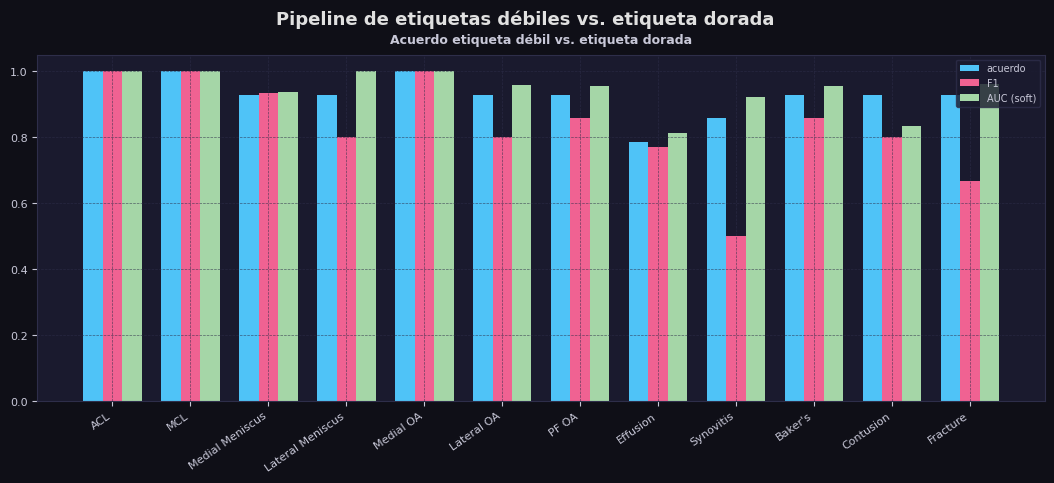

In [15]:
bundle = prepare(cfg, workers=cfg.num_workers or None)
display(bundle.agreement.round(3))
plot_agreement(bundle.agreement, "Pipeline de etiquetas débiles vs. etiqueta dorada", FIG_DIR / "weak_label_agreement.png")
plt.show()


In [16]:
state_cols = [f"state_{l}" for l in LABELS]
state_dist = (bundle.weak[state_cols].apply(pd.Series.value_counts).fillna(0).astype(int).T)
state_dist.index = LABELS
display(state_dist)


,ambiguous,neg,pos,pos_strong,unmentioned
ACL,18,37,0,28,7
MCL,0,68,3,7,12
Medial Meniscus,0,44,43,0,3
Lateral Meniscus,2,48,26,0,14
Medial OA,6,43,10,18,13
Lateral OA,7,43,0,21,19
PF OA,3,43,33,0,11
Effusion,0,38,0,35,17
Synovitis,0,51,26,0,13
Baker's,0,56,0,26,8


In [17]:
labeler, labeler_report = fit_tfidf_labeler(bundle)
display(labeler_report[labeler_report["label"] == "MACRO"][["labeler", "agreement", "kappa", "precision", "recall", "f1", "auc_soft"]].round(3))


,labeler,agreement,kappa,precision,recall,f1,auc_soft
12,rules,0.929,0.785,0.833,0.903,0.832,0.945
25,tfidf,0.804,0.405,0.536,0.649,0.536,0.769
38,rules+tfidf,0.923,0.701,0.750,0.819,0.749,0.933


Ejemplos de evidencia extraída, útiles para auditar el extractor por idioma:

In [18]:
sample = bundle.weak.merge(bundle.train[["StudyInstanceUID", bundle.report_col]], on="StudyInstanceUID")
for lab in ("ACL", "Effusion", "Fracture"):
    pos = sample[sample[f"state_{lab}"].isin(["pos", "pos_strong"])].head(2)
    for r in pos.itertuples():
        print(f"[{r.language}] {lab:9s} {getattr(r, f'state_{lab}'):10s} | {getattr(r, f'ev_{lab}')[:110]}")


[tr] ACL       pos_strong | on capraz bagda tam kat yirtik izlenmektedir.
[es] ACL       pos_strong | rotura completa del ligamento cruzado anterior.
[en] Effusion  pos_strong | large joint effusion.
[fr] Effusion  pos_strong | epanchement articulaire abondant.
[tr] Fracture  pos        | lateral tibia platosunda akut kirik.
[en] Fracture  pos        | acute fracture of the lateral tibial plateau.


## 16. Entregable 6 · Análisis del desbalance de clases

Prevalencia de cada hallazgo en la muestra de entrenamiento (target ≥ 0.5). Las mitigaciones implementadas y evaluadas en la ablación son: sobre-muestreo de estudios con positivos raros (`oversample_rare`), pérdida focal y `pos_weight` acotado.

,label,n_pos,prevalence,n_total,gold_prevalence
0,ACL,18,0.300,60,0.429
1,MCL,8,0.133,60,0.071
2,Medial Meniscus,27,0.450,60,0.571
3,Lateral Meniscus,17,0.283,60,0.214
4,Medial OA,17,0.283,60,0.214
5,Lateral OA,12,0.200,60,0.143
6,PF OA,21,0.350,60,0.214
7,Effusion,20,0.333,60,0.571
8,Synovitis,16,0.267,60,0.071
9,Baker's,17,0.283,60,0.214


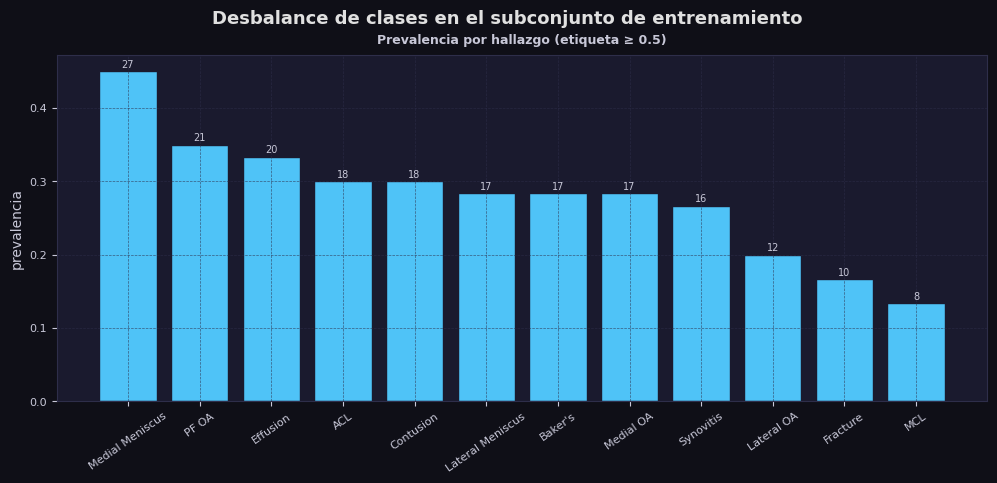

In [19]:
p_train, w_train = bundle.targets(bundle.weak_train_ids, cfg)
prevalence = prevalence_table(pd.DataFrame(p_train, columns=LABELS))
prevalence["gold_prevalence"] = bundle.gold_targets().mean(axis=0)
display(prevalence.round(3))
plot_prevalence(prevalence, "Desbalance de clases en el subconjunto de entrenamiento", FIG_DIR / "prevalence.png")
plt.show()


## 17. Entregable 2 · Entrenamiento de las dos arquitecturas

Ambas con BCE ponderada por confianza, plano sagital, mismo muestreo y misma cabeza de agregación.

[train] arch=scratch backbone=- params=1.28M loss=bce noise=weighted planes=('Sagittal',) device=cuda
  epoch=1 | train_loss=0.7066 | lr=0.0020 | time=20.7725 | gold_auc=0.5132 | holdout_auc=0.6636
  epoch=2 | train_loss=0.6210 | lr=0.0010 | time=0.2542 | gold_auc=0.5321 | holdout_auc=0.5052
  epoch=3 | train_loss=0.6123 | lr=0.0000 | time=0.2650 | gold_auc=0.5248 | holdout_auc=0.5424
[scratch_cnn_2p5d] gold macro AUC=0.5321 (best epoch 2)
[train] arch=timm backbone=resnet18 params=11.32M loss=bce noise=weighted planes=('Sagittal',) device=cuda
  epoch=1 | train_loss=0.7052 | lr=0.0020 | time=5.9266 | gold_auc=0.5850 | holdout_auc=0.5833
  epoch=2 | train_loss=0.6670 | lr=0.0010 | time=0.3175 | gold_auc=0.6919 | holdout_auc=0.6561
  epoch=3 | train_loss=0.6255 | lr=0.0000 | time=0.3017 | gold_auc=0.6802 | holdout_auc=0.6679
[transfer_resnet18] gold macro AUC=0.6919 (best epoch 2)


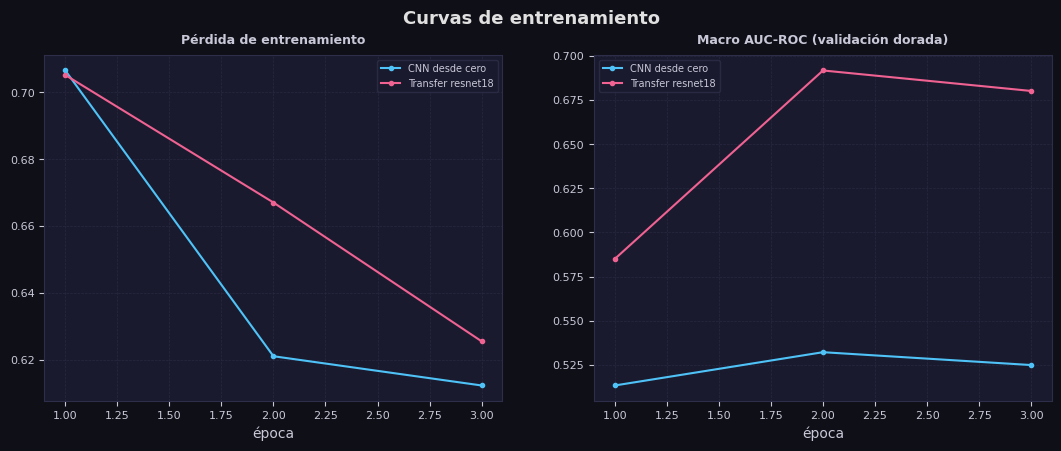

In [20]:
cfg_scratch = dataclasses.replace(cfg, arch="scratch", loss="bce", noise_strategy="weighted", planes=("Sagittal",))
cfg_transfer = dataclasses.replace(cfg, arch="timm", loss="bce", noise_strategy="weighted", planes=("Sagittal",))
exp_scratch = run_experiment(cfg_scratch, bundle, "scratch_cnn_2p5d")
exp_transfer = run_experiment(cfg_transfer, bundle, f"transfer_{cfg.backbone}")
plot_history({"CNN desde cero": exp_scratch["history"], f"Transfer {cfg.backbone}": exp_transfer["history"]},
             "Curvas de entrenamiento", FIG_DIR / "history_main.png")
plt.show()


## 18. Entregable 3 · Evaluación en el conjunto dorado

Macro AUC-ROC (métrica oficial), AUC por etiqueta y precisión/recall/F1 con umbral por etiqueta elegido en el *holdout* débil. Se incluye también el reporte con umbral fijo 0.5 para evidenciar el efecto de la calibración de umbrales.


CNN desde cero: macro AUC dorado = 0.5321 (época 2)


,label,n_pos,threshold,auc,precision,recall,f1
0,ACL,6,0.05,0.187,0.429,1.0,0.600
1,MCL,1,0.05,0.846,0.071,1.0,0.133
2,Medial Meniscus,8,0.05,0.750,0.571,1.0,0.727
3,Lateral Meniscus,3,0.05,0.152,0.214,1.0,0.353
4,Medial OA,3,0.05,0.636,0.214,1.0,0.353
5,Lateral OA,2,0.05,0.458,0.143,1.0,0.250
6,PF OA,3,0.05,0.318,0.214,1.0,0.353
7,Effusion,8,0.05,0.375,0.571,1.0,0.727
8,Synovitis,1,0.05,0.731,0.071,1.0,0.133
9,Baker's,3,0.05,0.561,0.214,1.0,0.353



Transfer resnet18: macro AUC dorado = 0.6919 (época 2)


,label,n_pos,threshold,auc,precision,recall,f1
0,ACL,6,0.25,1.000,1.000,1.000,1.000
1,MCL,1,0.05,0.615,0.071,1.000,0.133
2,Medial Meniscus,8,0.05,0.396,0.571,1.000,0.727
3,Lateral Meniscus,3,0.50,0.424,0.200,0.667,0.308
4,Medial OA,3,0.40,0.848,0.273,1.000,0.429
5,Lateral OA,2,0.05,0.750,0.143,1.000,0.250
6,PF OA,3,0.05,0.636,0.214,1.000,0.353
7,Effusion,8,0.35,0.958,1.000,0.500,0.667
8,Synovitis,1,0.55,0.923,0.077,1.000,0.143
9,Baker's,3,0.05,0.333,0.214,1.000,0.353


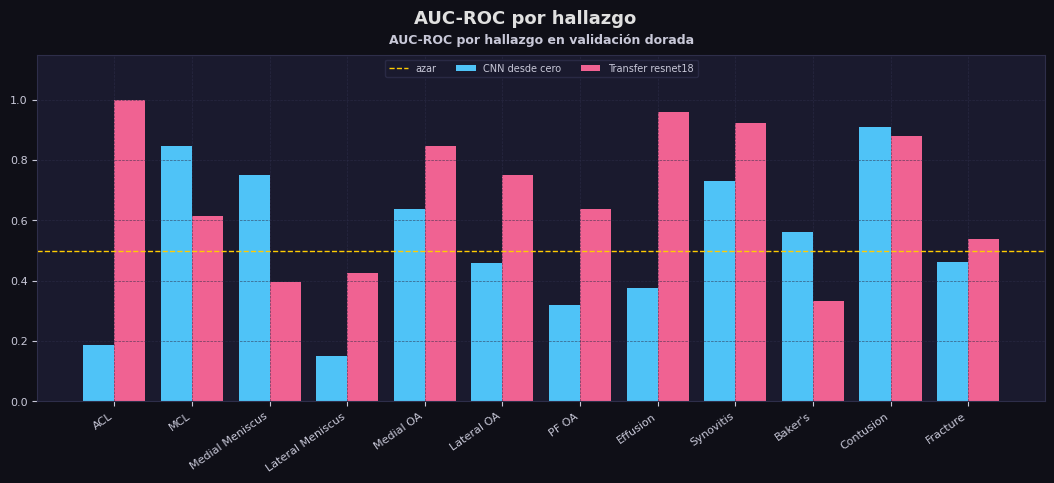

In [21]:
for name, exp in (("CNN desde cero", exp_scratch), (f"Transfer {cfg.backbone}", exp_transfer)):
    print(f"\n{name}: macro AUC dorado = {exp['gold_macro_auc']:.4f} (época {exp['best_epoch']})")
    display(exp["report"].round(3))
plot_per_label_auc({"CNN desde cero": exp_scratch["report"], f"Transfer {cfg.backbone}": exp_transfer["report"]},
                   "AUC-ROC por hallazgo", FIG_DIR / "per_label_auc_main.png")
plt.show()


In [22]:
comparison = pd.DataFrame({
    "modelo": ["CNN desde cero", f"Transfer {cfg.backbone}"],
    "macro_auc": [exp_scratch["gold_macro_auc"], exp_transfer["gold_macro_auc"]],
    "macro_f1_umbral_holdout": [exp_scratch["report"].iloc[-1]["f1"], exp_transfer["report"].iloc[-1]["f1"]],
    "macro_f1_umbral_0.5": [exp_scratch["report_05"].iloc[-1]["f1"], exp_transfer["report_05"].iloc[-1]["f1"]],
    "parametros_M": [count_params(exp_scratch["model"]) / 1e6, count_params(exp_transfer["model"]) / 1e6],
})
display(comparison.round(4))


,modelo,macro_auc,macro_f1_umbral_holdout,macro_f1_umbral_0.5,parametros_M
0,CNN desde cero,0.5321,0.3724,0.0611,1.2758
1,Transfer resnet18,0.6919,0.4081,0.1028,11.3151


## 19. Entregable 4 · Estudio de ablación

Factores: función de pérdida, estrategia frente a etiquetas ruidosas, plano de RM, profundidad del backbone y sobre-muestreo. Cada fila difiere de `transfer_bce_weighted` en un solo factor.

,name,arch,backbone,loss,noise_strategy,planes,gold_macro_auc,best_epoch,gold_f1_macro,oversample_rare
0,transfer_focal_weighted,timm,resnet18,focal,weighted,"(Sagittal,)",0.7179,3,0.4807,NaN
1,transfer_bce_shallow,timm,resnet18,bce,weighted,"(Sagittal,)",0.7026,3,0.4392,NaN
2,transfer_bce_coronal,timm,resnet18,bce,weighted,"(Coronal,)",0.6953,3,0.4831,NaN
3,transfer_bce_weighted,timm,resnet18,bce,weighted,"(Sagittal,)",0.6919,2,0.4081,NaN
4,transfer_bce_no_oversample,timm,resnet18,bce,weighted,"(Sagittal,)",0.6534,1,0.4200,False
5,transfer_bce_unweighted,timm,resnet18,bce,all,"(Sagittal,)",0.6263,3,0.4381,NaN
6,transfer_bce_highconf,timm,resnet18,bce,high_conf,"(Sagittal,)",0.5355,3,0.4418,NaN
7,scratch_cnn_2p5d,scratch,resnet18,bce,weighted,"(Sagittal,)",0.5321,2,0.3724,NaN


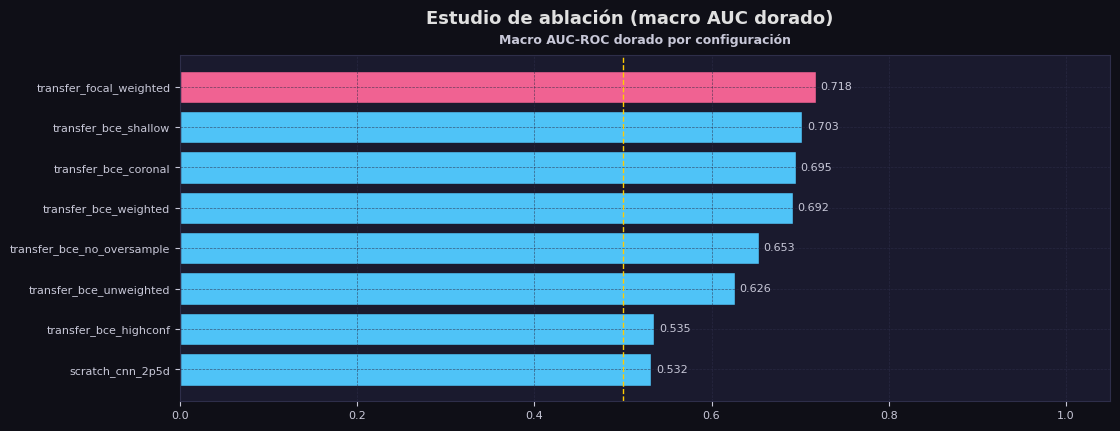

In [23]:
base_tl = {"arch": "timm", "backbone": cfg.backbone, "loss": "bce", "noise_strategy": "weighted", "planes": ("Sagittal",)}
grid = {
    "transfer_focal_weighted": {**base_tl, "loss": "focal"},
    "transfer_bce_highconf": {**base_tl, "noise_strategy": "high_conf"},
    "transfer_bce_unweighted": {**base_tl, "noise_strategy": "all"},
    "transfer_bce_coronal": {**base_tl, "planes": ("Coronal",)},
    "transfer_bce_shallow": {**base_tl, "backbone": "resnet18"},
    "transfer_bce_no_oversample": {**base_tl, "oversample_rare": False},
}
ablation_table, ablation_results = run_ablation(cfg, bundle, grid, verbose=False)
ablation_results["scratch_cnn_2p5d"] = exp_scratch
ablation_results["transfer_bce_weighted"] = exp_transfer
ablation_table = pd.concat([ablation_table, pd.DataFrame([
    {"name": "scratch_cnn_2p5d", **{k: v for k, v in dataclasses.asdict(cfg_scratch).items() if k in base_tl}, "gold_macro_auc": exp_scratch["gold_macro_auc"], "best_epoch": exp_scratch["best_epoch"], "gold_f1_macro": exp_scratch["report"].iloc[-1]["f1"]},
    {"name": "transfer_bce_weighted", **base_tl, "gold_macro_auc": exp_transfer["gold_macro_auc"], "best_epoch": exp_transfer["best_epoch"], "gold_f1_macro": exp_transfer["report"].iloc[-1]["f1"]},
])], ignore_index=True).sort_values("gold_macro_auc", ascending=False).reset_index(drop=True)
display(ablation_table.round(4))
plot_ablation(ablation_table, "Estudio de ablación (macro AUC dorado)", FIG_DIR / "ablation.png")
plt.show()


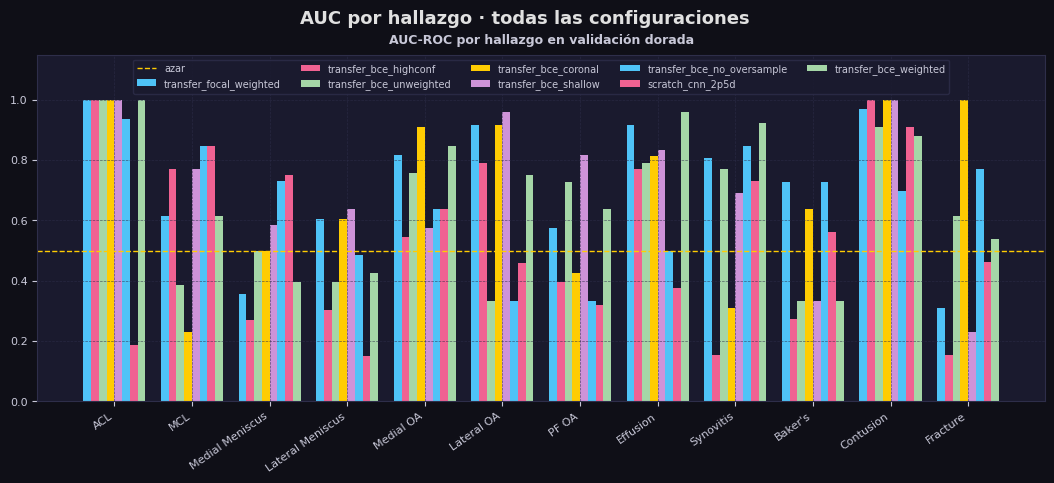

In [24]:
plot_per_label_auc({k: v["report"] for k, v in ablation_results.items()}, "AUC por hallazgo · todas las configuraciones", FIG_DIR / "per_label_auc_ablation.png")
plt.show()


## 20. Entregable 5 · Interpretabilidad con Grad-CAM

Para tres hallazgos se toma un estudio dorado positivo y se muestran los cortes con mayor atención junto al mapa de activación. La tabla `REGIONS` codifica, en coordenadas normalizadas del plano sagital, la zona anatómica esperada (LCA en el compartimento intercondíleo central, menisco medial en la interlínea posterior, derrame en el receso suprarrotuliano anterior) y `cam_stats` cuantifica qué fracción de la energía del mapa cae dentro de ella. Es una heurística de plausibilidad, no una segmentación.

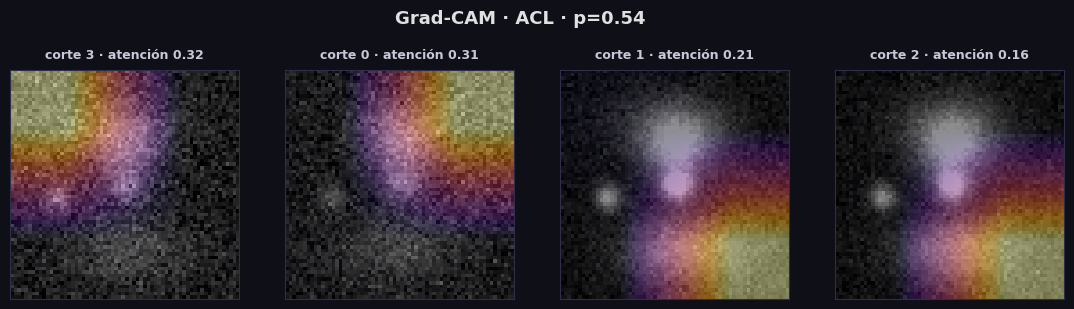

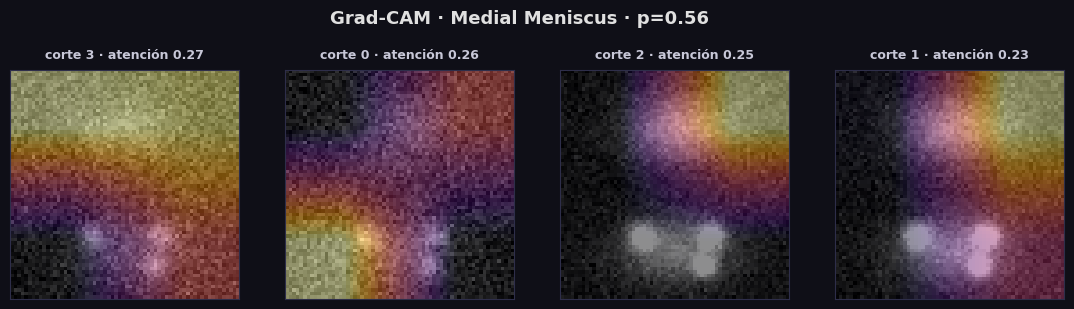

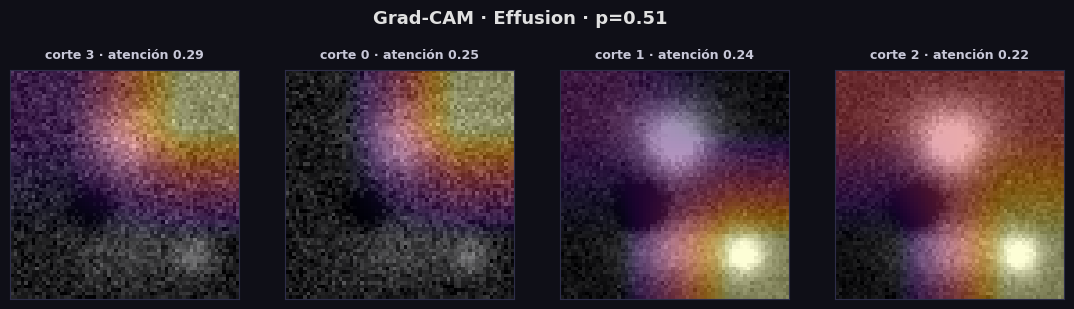

,label,study,prob,top_slice,energy_in_expected_region
0,ACL,1.2.826.0.1.9999.2,0.542,3,0.094
1,Medial Meniscus,1.2.826.0.1.9999.0,0.564,3,0.072
2,Effusion,1.2.826.0.1.9999.1,0.505,3,0.131


In [25]:
best_name = ablation_table.iloc[0]["name"]
best_exp = ablation_results[best_name]
best_cfg = dataclasses.replace(cfg, **{k: best_exp["config"][k] for k in ("arch", "backbone", "loss", "noise_strategy", "planes", "oversample_rare")})
best_cfg = dataclasses.replace(best_cfg, planes=tuple(best_cfg.planes))
model = best_exp["model"].cpu().float()
gold_y = bundle.gold_targets()
REGIONS = {"ACL": (0.35, 0.65, 0.35, 0.65), "Medial Meniscus": (0.55, 0.80, 0.45, 0.80), "Effusion": (0.10, 0.45, 0.15, 0.50)}
cam_rows = []
for lab, region in REGIONS.items():
    j = LABELS.index(lab)
    candidates = [i for i in range(len(bundle.gold_ids)) if gold_y[i, j] >= 0.5]
    if not candidates:
        continue
    i = candidates[0]
    x = KneeStudyDataset(best_cfg, [bundle.gold_ids[i]], gold_y[i:i + 1], np.ones((1, len(LABELS))),
                         train=False, imagenet_norm=best_cfg.arch != "scratch")[0]["x"]
    g = gradcam_study(model, x, lab)
    plot_gradcam(x.numpy(), g["cam"], g["attention"], lab, g["prob"], path=FIG_DIR / f"gradcam_{lab.replace(' ', '_')}.png")
    plt.show()
    cam_rows.append({"label": lab, "study": bundle.gold_ids[i], "prob": g["prob"], "top_slice": g["top_slice"],
                     "energy_in_expected_region": cam_stats(g["cam"][g["top_slice"]], region)})
display(pd.DataFrame(cam_rows).round(3))


## 21. Entregable 7 · Sesgo geográfico y lingüístico

La calidad del extractor no es uniforme entre idiomas: la tabla muestra acuerdo celda a celda y tasa de sobre-llamada por idioma en los estudios dorados. Con 58 estudios el tamaño por idioma es pequeño, por lo que las diferencias son direccionales y deben leerse junto al conteo `n`.

,language,n_studies,cell_agreement,overcall_rate,undercall_rate
0,en,5,0.950,0.050,0.000
1,tr,4,0.896,0.042,0.062
2,es,2,0.917,0.042,0.042
3,fr,2,0.958,0.000,0.042
4,de,1,0.917,0.000,0.083


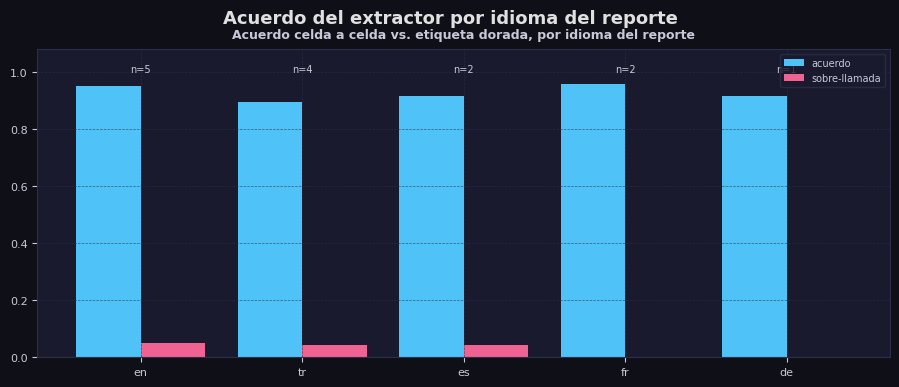

In [26]:
display(bundle.agreement_lang.round(3))
plot_language_agreement(bundle.agreement_lang, "Acuerdo del extractor por idioma del reporte", FIG_DIR / "language_agreement.png")
plt.show()


**Discusión.** El extractor se diseñó con léxicos para doce idiomas, pero su cobertura es asimétrica: los patrones de negación posterior (turco `izlenmedi`), la ausencia de diacríticos en cirílico y griego, y la variabilidad terminológica de los compartimentos de artrosis fueron auditados con ejemplos, no con un corpus anotado por idioma. Un idioma con menor cobertura produce más celdas `unmentioned` o `ambiguous`, es decir, targets cercanos a 0 con peso bajo: el clasificador de imágenes aprende que los estudios de ese centro son "más sanos", y el sesgo de etiqueta se convierte en sesgo de imagen porque el idioma está correlacionado con el centro, el escáner y el protocolo. En un despliegue clínico esto implica (i) validar el rendimiento estratificado por centro/idioma antes de liberar el modelo, (ii) exigir un mínimo de estudios con etiqueta verificada por idioma para calibrar el extractor y (iii) monitorizar la deriva cuando se incorporen nuevos centros, ya que el AUC macro global puede ocultar un rendimiento cercano al azar en un subgrupo.

## 22. Exportación de artefactos

In [28]:
summary = {
    "mode": MODE,
    "best_experiment": best_name,
    "gold_macro_auc": float(best_exp["gold_macro_auc"]),
    "main_models": comparison.to_dict(orient="records"),
    "ablation": ablation_table.to_dict(orient="records"),
    "weak_label_macro": bundle.agreement.iloc[-1].to_dict(),
    "gradcam": cam_rows,
    "config": cfg.to_dict(),
}
(cfg.work_dir / "results.json").write_text(json.dumps(summary, indent=1, default=str))
print(json.dumps({k: summary[k] for k in ("mode", "best_experiment", "gold_macro_auc")}, indent=1))
print(sorted(p.name for p in FIG_DIR.iterdir()))


{
 "mode": "mock",
 "best_experiment": "transfer_focal_weighted",
 "gold_macro_auc": 0.7179365773115775
}
['ablation.png', 'gradcam_ACL.png', 'gradcam_Effusion.png', 'gradcam_Medial_Meniscus.png', 'history_main.png', 'language_agreement.png', 'per_label_auc_ablation.png', 'per_label_auc_main.png', 'prevalence.png', 'weak_label_agreement.png']
